# Qwen3VL-4B LoRA Fine-tuning on BDD100K, Eval & Analysis

This notebook provides an optimized workflow for:
- Setting up Qwen3VL-4B with LoRA fine-tuning
- Training on BDD100K dataset (JSONL format)
- Real-time monitoring and visualization
- Quantitative and Qualitative analysis (XAI techniques)

### System Requirements:
- VRAM: 24GB+ NVIDIA GeForce RTX 5090
- Python version 3.11.9
- Framework: HuggingFace Transformers + PEFT
- Optimization: LoRA with gradient checkpointing and vision token capping 


## 1. Environment Setup and Dependencies

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# CRITICAL: Fix for Multi-GPU DataLoader hanging in Jupyter environments
import multiprocessing
if __name__ == '__main__':
    try:
        multiprocessing.set_start_method('spawn', force=True)
        print("Multiprocessing start method set to 'spawn'")
    except RuntimeError:
        pass

Multiprocessing start method set to 'spawn'


In [ ]:
# Install required packages for Qwen3VL training
%pip install -q peft==0.11.0
%pip install -q datasets==2.19.0
%pip install -q torch torchvision
%pip install -q wandb
%pip install -q matplotlib seaborn scikit-learn
%pip install -q tqdm
%pip install -q numpy pandas pillow flash-attn --no-build-isolation
%pip install hf_xet #important for faster hf downloads

In [3]:
import accelerate
import peft
import transformers

print(accelerate.__version__)
print(peft.__version__)
print(transformers.__version__)

1.13.0
0.11.0
4.57.0


In [4]:
# Import all required libraries
import os
import sys
import json
import warnings
from pathlib import Path
from datetime import datetime

# Data handling
import numpy as np
import pandas as pd
from PIL import Image

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader

# Progress bars
from tqdm.auto import tqdm

# HuggingFace - Model loading and training
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    TrainingArguments,
    Trainer,
)

# PEFT - Parameter Efficient Fine-Tuning (LoRA)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

# HuggingFace Datasets
from datasets import load_dataset, DatasetDict

# Supporting libraries
import accelerate
import bitsandbytes as bnb
import wandb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

warnings.filterwarnings("ignore")
print("All imports successful")

W0706 09:45:35.648000 6700 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


All imports successful


In [5]:
# Check GPU availability and setup device
# This determines where tensors will be computed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        memory_gb = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  Total Memory: {memory_gb:.2f} GB")

Device: cuda
CUDA Available: True
GPU Count: 1
GPU 0: NVIDIA GeForce RTX 5090
  Total Memory: 34.19 GB


## 2. Configuration and Hyperparameters

In [8]:
# Global configuration - Optimized for Speed and Throughput
# Modify these values to adapt the training to your setup
CONFIG = {
    "model_name": "Qwen/Qwen3-VL-4B-Instruct",
    "model_type": "qwen3_vl",

    # Dataset paths
    "dataset_format": "jsonl",
    "train_jsonl": r"C:/Users/becker/Documents/Thesis/dataset/train.jsonl",
    "val_jsonl": r"C:/Users/becker/Documents/Thesis/dataset/val.jsonl",
    "image_base_path": r"C:/Users/becker/Documents/Thesis/dataset/images",

    # LoRA configuration
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "target_modules": [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    "bias": "none",

    # OPTIMIZED TRAINING HYPERPARAMETERS
    "batch_size": 4,                     
    "gradient_accumulation_steps": 2,    
    "learning_rate": 2e-4,                
    "warmup_steps": 200,
    "num_train_epochs": 1,
    "max_steps": -1,
    "weight_decay": 0.01,

    # Memory and precision optimizations
    "gradient_checkpointing": True,       
    "bf16": True,
    "tf32": True,
    "max_grad_norm": 1.0,

    # Image resolution token limits (Exponential speedup for VLMs)
    "min_pixels": 256 * 256,
    "max_pixels": 384 * 384,              # Caps sequence lengths to prevent token explosion

    # Saving and evaluation strategies (Reduced frequency to save overhead)
    "output_dir": r"./qwen3vl_bdd100k_lora",
    "save_strategy": "steps",
    "eval_strategy": "steps",
    "save_steps": 1000,
    "eval_steps": 1000,
    "logging_steps": 20,
    "save_total_limit": 2,
    "load_best_model_at_end": True,
    "metric_for_best_model": "loss",

    "use_wandb": False,
    "project_name": "qwen3vl-bdd100k",
    "run_name": f"qwen3vl-lora-{datetime.now().strftime('%Y%m%d_%H%M%S')}",

    "seed": 42,
    "dataloader_num_workers": 0,          # Enabled workers to handle high-speed image preprocessing, change to 2 on another train try
    "dataloader_pin_memory": True,
    "remove_unused_columns": False,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
with open(os.path.join(CONFIG["output_dir"], "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Configuration optimized and loaded.")
print(f"Effective Batch Size: {CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps'] * 2} ")

Configuration optimized and loaded.
Effective Batch Size: 16 


In [9]:
#Make sure all paths and files exist before proceeding with training
print("Validating paths and files...")
print("-" * 80)

jsonl_files = [
    ("Train JSONL", CONFIG["train_jsonl"]),
    ("Val JSONL", CONFIG["val_jsonl"]),
]

all_exist = True
for name, path in jsonl_files:
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    print(f"[{status}] {name}: {path}")
    if not exists:
        all_exist = False

image_path_exists = os.path.exists(CONFIG["image_base_path"])
status = "OK" if image_path_exists else "MISSING"
print(f"[{status}] Image Base Path: {CONFIG['image_base_path']}")
if not image_path_exists:
    all_exist = False

print("-" * 80)
if all_exist:
    print("Validation complete. All files ready.")

Validating paths and files...
--------------------------------------------------------------------------------
[OK] Train JSONL: C:/Users/becker/Documents/Thesis/dataset/train.jsonl
[OK] Val JSONL: C:/Users/becker/Documents/Thesis/dataset/val.jsonl
[OK] Image Base Path: C:/Users/becker/Documents/Thesis/dataset/images
--------------------------------------------------------------------------------
Validation complete. All files ready.


## 3. Load Model and Processor

In [10]:
print("Loading optimized model and processor...")
processor = AutoProcessor.from_pretrained(CONFIG["model_name"])

model = AutoModelForImageTextToText.from_pretrained(
    CONFIG["model_name"],
    # device_map="auto",
    dtype=torch.bfloat16,
    attn_implementation="sdpa", 
    trust_remote_code=True,
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Total parameters: {total_params / 1e9:.2f}B")

Loading optimized model and processor...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded. Total parameters: 4.44B


## 4. BDD100K Dataset Class Definition

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

# Inject yor resolution limits directly into the processor global settings
# This ensures SFTTrainer respects speed targets automatically during collation
processor.image_processor.min_pixels = CONFIG["min_pixels"]
processor.image_processor.max_pixels = CONFIG["max_pixels"]


class BDD100KDataset(Dataset):
    def __init__(self, jsonl_path, image_base_path="", max_samples=None):
        self.jsonl_path = jsonl_path
        self.image_base_path = image_base_path
        self.samples = []

        print(f"Loading data from {os.path.basename(jsonl_path)}...")
        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    sample = json.loads(line.strip())
                    self.samples.append(sample)
                    if max_samples and len(self.samples) >= max_samples:
                        break
                except json.JSONDecodeError:
                    continue

        print(f"Loaded {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Pull the image path directly from the root key
        image_path = sample.get("image", "")
        
        if self.image_base_path and not os.path.isabs(image_path):
            full_image_path = os.path.join(self.image_base_path, image_path)
        else:
            full_image_path = image_path

        # Safely resolve and open the image
        try:
            image = Image.open(full_image_path).convert("RGB")
        except Exception as e:
            print(f"Warning: Could not load {full_image_path}. Using fallback canvas. Error: {e}")
            # Use your optimized fast resolution size as a fallback canvas
            image = Image.new("RGB", (384, 384), color="black")

        # Pass the raw elements to the trainer.
        # SFTTrainer will automatically handle tokenization and create the perfect loss masks.
        return {
            "messages": sample["messages"],
            "images": [image]  # Qwen processor expects images inside a list wrapper
        }

## 5. Load Training, Validation

In [ ]:
print("Loading datasets...")
try:
    train_dataset = BDD100KDataset(CONFIG["train_jsonl"], image_base_path=CONFIG["image_base_path"])
    val_dataset = BDD100KDataset(CONFIG["val_jsonl"], image_base_path=CONFIG["image_base_path"])
except Exception as e:
    print(f"Error loading datasets: {e}")
    raise

# Calculate accurate step metrics based on your actual gradient accumulation choices
total_samples = len(train_dataset)
steps_per_epoch = total_samples // (CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps'])

print("\n--- Dataset Profile ---")
print(f"Train samples loaded: {total_samples}")
print(f"Validation samples loaded: {len(val_dataset)}")
print(f"Optimization Steps per Epoch: {steps_per_epoch}")
print(f"Total Projected Training Steps (across {CONFIG['num_train_epochs']} epochs): {steps_per_epoch * CONFIG['num_train_epochs']}")

Loading datasets...
Loading data from train.jsonl...
Loaded 393277 samples
Loading data from val.jsonl...
Loaded 56199 samples

--- Dataset Profile ---
Train samples loaded: 393277
Validation samples loaded: 56199
Optimization Steps per Epoch: 49159
Total Projected Training Steps (across 1 epochs): 49159


In [ ]:
print("Verifying layout token size drops...")

# Grab the raw sample from our updated dataset
sample = train_dataset[0]
print(f"Raw image format: {type(sample['images'][0])}")
print(f"Original image resolution (Width, Height): {sample['images'][0].size}")

# Simulate what the data collator does using your CONFIG limits
mock_processed = processor(
    text=["<|im_start|>user\n<|image_pad|><|im_end|>"], 
    images=sample['images'],
    return_tensors="pt",
    min_pixels=CONFIG["min_pixels"],
    max_pixels=CONFIG["max_pixels"]
)

print(f"Capped Vision Pixel Tensor Shape: {mock_processed['pixel_values'].shape}")

# For Qwen3-VL, image_grid_thw tells you exactly how many patches are generated
if "image_grid_thw" in mock_processed:
    grid = mock_processed["image_grid_thw"]
    print(f"Image Grid patches [Temporal, Height, Width]: {grid.tolist()[0]}")
    print(f"Total Visual Tokens generated for this image: {grid[0][1] * grid[0][2]}")

Verifying layout token size drops...
Raw image format: <class 'PIL.Image.Image'>
Original image resolution (Width, Height): (1280, 720)
Capped Vision Pixel Tensor Shape: torch.Size([576, 1536])
Image Grid patches [Temporal, Height, Width]: [1, 18, 32]
Total Visual Tokens generated for this image: 576


## 6. LoRA Configuration and Model Preparation

In [38]:
print("Preparing model with LoRA adaptations...")

if CONFIG["gradient_checkpointing"]:
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing verified active.")

if hasattr(model, 'enable_input_require_grads'):
    model.enable_input_require_grads()

lora_config = LoraConfig(
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    target_modules=CONFIG["target_modules"],
    lora_dropout=CONFIG["lora_dropout"],
    bias=CONFIG["bias"],
    task_type="CAUSAL_LM",
)
# Apply LoRA to model
model = get_peft_model(model, lora_config)
# Print trainable parameter statistics
model.print_trainable_parameters()
print()
print("LoRA configuration applied to model")
print(f"  Rank (r): {CONFIG['lora_r']}")
print(f"  Alpha: {CONFIG['lora_alpha']}")
print(f"  Dropout: {CONFIG['lora_dropout']}")
print(f"  Target modules: {len(CONFIG['target_modules'])} layers")
print()
print("Model is now ready for training")

Preparing model with LoRA adaptations...
Gradient checkpointing verified active.
trainable params: 33,030,144 || all params: 4,470,845,952 || trainable%: 0.7388

LoRA configuration applied to model
  Rank (r): 16
  Alpha: 32
  Dropout: 0.05
  Target modules: 7 layers

Model is now ready for training


## 7. Training Setup and Execution

In [14]:
# Configure training arguments for HuggingFace Trainer
training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_train_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    learning_rate=CONFIG["learning_rate"],
    warmup_steps=CONFIG["warmup_steps"],
    weight_decay=CONFIG["weight_decay"],
    
    bf16=CONFIG["bf16"],
    tf32=CONFIG["tf32"],
    max_grad_norm=CONFIG["max_grad_norm"],
    gradient_checkpointing=CONFIG["gradient_checkpointing"],
    
    eval_strategy=CONFIG["eval_strategy"],
    eval_steps=CONFIG["eval_steps"],
    save_strategy=CONFIG["save_strategy"],
    save_steps=CONFIG["save_steps"],
    logging_steps=CONFIG["logging_steps"],
    save_total_limit=CONFIG["save_total_limit"],
    load_best_model_at_end=CONFIG["load_best_model_at_end"],
    metric_for_best_model=CONFIG["metric_for_best_model"],
    
    seed=CONFIG["seed"],
    dataloader_num_workers=CONFIG["dataloader_num_workers"],
    dataloader_pin_memory=CONFIG["dataloader_pin_memory"],
    remove_unused_columns=CONFIG["remove_unused_columns"],
    report_to="none",
)
print(" Training arguments configured")
print(f"  Epochs: {CONFIG['num_train_epochs']}")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Eval steps:  {CONFIG['eval_steps']}")


 Training arguments configured
  Epochs: 1
  Batch size: 4
  Eval steps:  1000


In [ ]:
#VisionCollator

from typing import Dict, List, Any
import torch

class VisionLanguageCollator:
    def __init__(self, processor, min_pixels, max_pixels):
        self.processor = processor
        self.min_pixels = min_pixels
        self.max_pixels = max_pixels
        
        # DYNAMICALLY detect the exact token sequence for '<|im_start|>assistant\n'
        self.assistant_prefix = self.processor.tokenizer.encode(
            "<|im_start|>assistant\n", 
            add_special_tokens=False
        )

    def __call__(self, batch: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # Reconstruct texts and collect raw images from our clean dataset elements
        texts = []
        images = []
        
        for sample in batch:
            # Render the correct structural text tokens using the official chat layout
            prompt = self.processor.apply_chat_template(
                sample["messages"], 
                tokenize=False, 
                add_generation_prompt=False
            )
            texts.append(prompt)
            # Extends the list with the raw PIL image object
            images.extend(sample["images"])

        # Let the processor safely batch tokenise and adjust aspect ratios
        processed = self.processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=False,
            min_pixels=self.min_pixels,
            max_pixels=self.max_pixels
        )

        input_ids = processed["input_ids"]
        attention_mask = processed["attention_mask"]
        
        # Build target labels matching input_ids
        labels = input_ids.clone()
        pad_token_id = self.processor.tokenizer.pad_token_id or 0

        # Target-Only Loss Masking per row
        for i in range(labels.shape[0]):
            seq_list = input_ids[i].tolist()
            assistant_idx = self._find_sublist(seq_list, self.assistant_prefix)
            
            if assistant_idx != -1:
                # Mask out all system prompts, user questions, and vision tokens with -100
                cutoff = assistant_idx + len(self.assistant_prefix)
                labels[i, :cutoff] = -100
            else:
                # Fallback safeguard if the assistant token sequence isn't found
                labels[i, :] = -100
                
        # Mask out any trailing padding tokens
        labels[labels == pad_token_id] = -100

        # Pack everything safely for the model
        output = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "pixel_values": processed["pixel_values"],
            "labels": labels,
        }
        
        # Preserve specialized positional metadata if generated by the processor
        if "image_grid_thw" in processed:
            output["image_grid_thw"] = processed["image_grid_thw"]
            
        return output

    def _find_sublist(self, main_list, sub_list):
        for idx in range(len(main_list) - len(sub_list) + 1):
            if main_list[idx : idx + len(sub_list)] == sub_list:
                return idx
        return -1

# Instantiate dynamic collator safely
data_collator = VisionLanguageCollator(
    processor=processor,
    min_pixels=CONFIG["min_pixels"],
    max_pixels=CONFIG["max_pixels"]
)
print("VisionLanguageCollator successfully initialized!")

VisionLanguageCollator successfully initialized!


In [ ]:
import traceback
import torch

print("Verifying gradient pathways via an isolated single-threaded batch...")

# Force the target to your RTX 5090
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Moving model weights explicitly to: {device}")

try:
    # Safely push the model to the GPU since it was loaded on the CPU
    model.to(device)
    model.train()

    # Grab raw samples and collate them manually
    raw_samples = [train_dataset[i] for i in range(2)]  
    sample_batch = data_collator(raw_samples)          

    # Cast batch tensors to match the GPU device
    inputs = {
        k: v.to(device) if isinstance(v, torch.Tensor) else v
        for k, v in sample_batch.items()
    }

    # Compute loss forward pass
    outputs = model(**inputs)
    loss = outputs.loss if hasattr(outputs, "loss") else outputs[0]
    print(f"Isolated Batch Loss computed successfully: {loss.item():.6f}")

    # Trigger backward pass calculation
    loss.backward()

    # Check if weights across LoRA targets received active gradients
    gradient_flow_ok = False
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            grad_norm = param.grad.norm().item()
            if grad_norm > 0:
                gradient_flow_ok = True
                print(f"  [Success] Active gradient found on target: {name} (Norm: {grad_norm:.6f})")
                break  

    if gradient_flow_ok:
        print("\nVerification PASSED: Gradient flow pathways successfully initialized.")
    else:
        print("\nVerification FAILED: Parameters are locked or gradients are zero.")

except Exception as e:
    gradient_flow_ok = False
    print(f"\nVerification blocked by runtime error: {e}")
    traceback.print_exc()

finally:
    # Flush the test gradients, but LEAVE the model on the GPU
    if "model" in locals():
        model.zero_grad()
        print("Gradients flushed clean. Model remains securely on the GPU for training.")

Verifying gradient pathways via an isolated single-threaded batch...
Moving model weights explicitly to: cuda:0


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Isolated Batch Loss computed successfully: 1.397900
  [Success] Active gradient found on target: base_model.model.base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_B.default.weight (Norm: 0.052490)

Verification PASSED: Gradient flow pathways successfully initialized.
Gradients flushed clean. Model remains securely on the GPU for training.


In [ ]:
# Main training cell
# Start training ONLY if verification passed

from transformers import TrainingArguments, Trainer

# Start training ONLY if verification passed
if not gradient_flow_ok:
    print("Halted due to verification failure.")
else:
    print("Initializing Training Configuration...")
    training_args = TrainingArguments(
        output_dir=CONFIG["output_dir"],
        save_strategy=CONFIG["save_strategy"],
        eval_strategy=CONFIG["eval_strategy"],
        save_steps=CONFIG["save_steps"],
        eval_steps=CONFIG["eval_steps"],
        logging_steps=CONFIG["logging_steps"],
        save_total_limit=CONFIG["save_total_limit"],
        load_best_model_at_end=CONFIG["load_best_model_at_end"],
        metric_for_best_model=CONFIG["metric_for_best_model"],
        
        # Sizing optimized for RTX 5090 speed targets
        per_device_train_batch_size=CONFIG["batch_size"],
        per_device_eval_batch_size=CONFIG["batch_size"],
        gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
        
        learning_rate=CONFIG["learning_rate"],
        warmup_steps=CONFIG["warmup_steps"],
        num_train_epochs=CONFIG["num_train_epochs"],
        weight_decay=CONFIG["weight_decay"],
        max_grad_norm=CONFIG["max_grad_norm"],
        
        # Speed & Precision options
        bf16=CONFIG["bf16"],
        tf32=CONFIG["tf32"],
        gradient_checkpointing=CONFIG["gradient_checkpointing"],
        
        dataloader_num_workers=CONFIG["dataloader_num_workers"],
        dataloader_pin_memory=CONFIG["dataloader_pin_memory"],
        remove_unused_columns=CONFIG["remove_unused_columns"],
        report_to="none",
        seed=CONFIG["seed"]
    )

    print("Assembling Trainer pipeline...")
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator  
    )
    print("Trainer successfully initialized.")
    
    print("Starting optimized training loop...")
    try:
        trainer.train() #comment to run more analysis on the training without trigerring another train run
        print("Training complete.")
    except KeyboardInterrupt:
        print("Training paused by user.")

Initializing Training Configuration...
Assembling Trainer pipeline...
Trainer successfully initialized.
Starting optimized training loop...


Step,Training Loss,Validation Loss
1000,0.387400,0.396490
2000,0.380800,0.389348
3000,0.390800,0.388845
4000,0.353700,0.383604
5000,0.370900,0.381374
6000,0.364200,0.381872
7000,0.363200,0.381261
8000,0.363400,0.376550
9000,0.373600,0.374413
10000,0.376600,0.374850


Training complete.


## 8. Save Trained Model
 The model directory contains LoRA weights, config, and processor files necessary for loading and inference

In [18]:
# Save the trained LoRA model for later inference
lora_save_path = os.path.join(CONFIG["output_dir"], "final_model")
os.makedirs(lora_save_path, exist_ok=True)
model.save_pretrained(lora_save_path)
processor.save_pretrained(lora_save_path)
print(f"Optimized Model weights preserved at {lora_save_path}")

Optimized Model weights preserved at ./qwen3vl_bdd100k_lora\final_model


**Visualize training results**

Upgraded chart exported to: C:\Users\becker\Documents\Thesis\qwen3vl_bdd100k_lora\train_val_loss.png


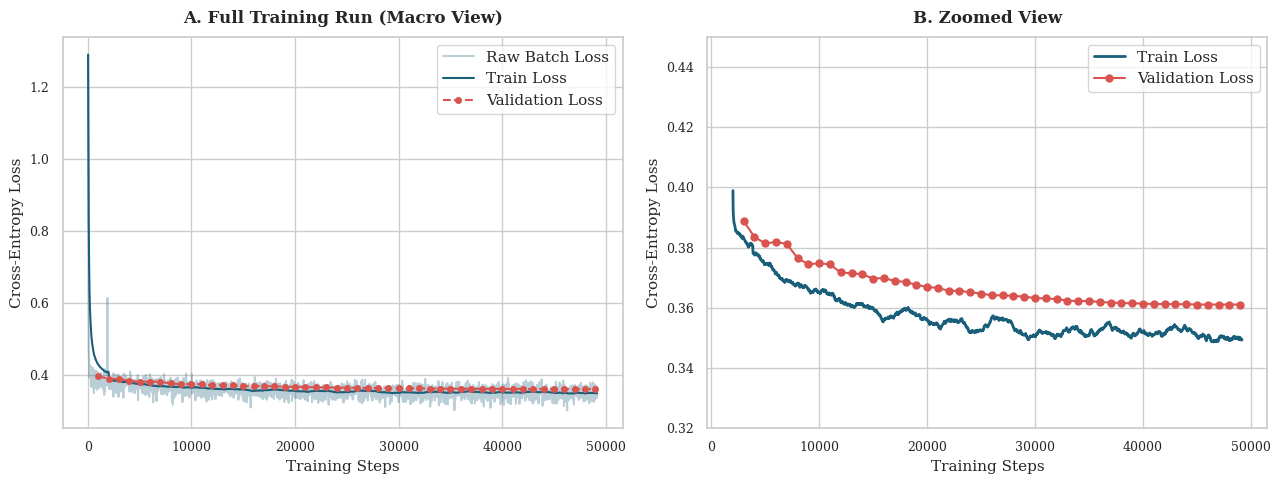

In [61]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean, publication-ready thesis styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif", 
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

# Read history from your checkpoint folder
state_path = r"C:\Users\becker\Documents\Thesis\qwen3vl_bdd100k_lora\checkpoint-49160\trainer_state.json"
with open(state_path, "r") as f:
    state_data = json.load(f)
    history = state_data.get("log_history", [])

# Separate metrics
train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

for log in history:
    if "loss" in log:
        train_steps.append(log["step"])
        train_losses.append(log["loss"])
    if "eval_loss" in log and "step" in log:
        eval_steps.append(log["step"])
        eval_losses.append(log["eval_loss"])

# Convert to Pandas for smoothing operations
df_train = pd.DataFrame({"step": train_steps, "loss": train_losses})
# Apply a rolling average window to smooth out high-frequency batch noise
df_train["smoothed_loss"] = df_train["loss"].rolling(window=100, min_periods=1).mean()

# Create a Side-by-Side Double Subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df_train["step"], df_train["loss"], color="#1a5f7a", alpha=0.3, label="Raw Batch Loss")
ax1.plot(df_train["step"], df_train["smoothed_loss"], color="#1a5f7a", linewidth=1.5, label="Train Loss")
ax1.plot(eval_steps, eval_losses, color="#d9534f", linestyle="--", marker="o", markersize=4, label="Validation Loss")

ax1.set_title("A. Full Training Run (Macro View)", weight="bold", pad=10)
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend(loc="upper right", frameon=True, facecolor="white")

# Filter out the initial burn-in phase 
df_zoomed = df_train[df_train["step"] > 2000]
eval_zoomed_steps = [s for s in eval_steps if s > 2000]
eval_zoomed_losses = [l for s, l in zip(eval_steps, eval_losses) if s > 2000]

ax2.plot(df_zoomed["step"], df_zoomed["smoothed_loss"], color="#1a5f7a", linewidth=2, label="Train Loss")
ax2.plot(eval_zoomed_steps, eval_zoomed_losses, color="#d9534f", linestyle="-", marker="o", markersize=5, label="Validation Loss")

# Set strict Y-limits to intentionally blow up the micro-trends
ax2.set_ylim(0.32, 0.45) 
ax2.set_title("B. Zoomed View", weight="bold", pad=10)
ax2.set_xlabel("Training Steps")
ax2.set_ylabel("Cross-Entropy Loss")
ax2.legend(loc="upper right", frameon=True, facecolor="white")

plt.tight_layout()

# Save the upgraded figure
save_dir = r"C:\Users\becker\Documents\Thesis\qwen3vl_bdd100k_lora"
save_path = os.path.join(save_dir, "train_val_loss.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Upgraded chart exported to: {save_path}")
plt.show()

## 9. Evaluate on Test Dataset
- Catches Overfitting (The Loss Check)
- Benchmarks Speed and Efficiency
- Acts as a Safety Net

In [19]:
print("Running final check over validation split...")
# Leaving this empty automatically evaluates the model on your validation dataset
eval_results = trainer.evaluate() 

print("Final Evaluation Results:")
print("-" * 80)
for key, value in eval_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Save results
results_path = os.path.join(CONFIG["output_dir"], "final_evaluation_results.json")
with open(results_path, "w") as f:
    json.dump(eval_results, f, indent=2)

print()
print(f"Results saved to {results_path}")

Running final check over validation split...


Final Evaluation Results:
--------------------------------------------------------------------------------
eval_loss: 0.3611
eval_runtime: 3794.5315
eval_samples_per_second: 14.8110
eval_steps_per_second: 3.7030
epoch: 1.0000

Results saved to ./qwen3vl_bdd100k_lora\final_evaluation_results.json


## 10. Inference with Trained Model

In [13]:
#Load Trained Model
import torch
from transformers import AutoModelForVision2Seq, AutoProcessor
from peft import PeftModel

# Define the exact path 
SAVED_MODEL_PATH = r"C:\Users\becker\Documents\Thesis\qwen3vl_bdd100k_lora\final_model"
BASE_MODEL_NAME = "Qwen/Qwen3-VL-4B-Instruct" 

print("Loading base model and processor...")
processor = AutoProcessor.from_pretrained(SAVED_MODEL_PATH)
base_model = AutoModelForVision2Seq.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("Loading and fusing your fine-tuned LoRA adapters...")
inference_model = PeftModel.from_pretrained(base_model, SAVED_MODEL_PATH)
inference_model.eval() # Set to evaluation mode

print("Model successfully loaded from disk and ready for inference!")

Loading base model and processor...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading and fusing your fine-tuned LoRA adapters...
Model successfully loaded from disk and ready for inference!


In [16]:
model.to("cuda")

Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(
    (visual): Qwen3VLVisionModel(
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 1024)
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-23): 24 x Qwen3VLVisionBlock(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True, bias=True)
          (attn): Qwen3VLVisionAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): Qwen3VLVisionMLP(
            (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (linear_fc2): Linear(in_features=4096, out_features=1024, bias=True)
            (act_fn): GELUTanh()
         

**Sandbox test to check if weights are working**

In [17]:
import os
import torch
from PIL import Image

def generate_response_debug(image_path, prompt, model, processor, max_length=512):
    print("START DEBUG INFERENCE")
    
    # Load and format image
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"CRITICAL ERROR: The file path does not exist: {image_path}")
        
    image = Image.open(image_path).convert("RGB")
    print(f"Step 1: Image Loaded successfully. Size: {image.size}")
    
    # Format the prompt using Qwen's specific template structure
    conversation = [
        {
            "role": "user",
            "content": [{"type": "image"}, {"type": "text", "text": prompt}],
        }
    ]
    text_prompt = processor.apply_chat_template(
        conversation, tokenize=False, add_generation_prompt=True
    )
    print(f"Step 2: Formatted Text Prompt:\n{text_prompt}")
    
    # Process inputs with your exact training configurations (384x384 max)
    inputs = processor(
        text=[text_prompt],
        images=[image],
        return_tensors="pt",
        min_pixels=256 * 256,  
        max_pixels=384 * 384   
    )
    print(f"Step 3: Processor finished. Input IDs shape: {inputs['input_ids'].shape}")
    
    # Safely move all tensors to the GPU
    inputs = inputs.to(model.device)
    print(f"Step 4: Tensors successfully routed to device: {model.device}")
    
    # Generate text tokens cleanly
    print("Step 5: Sending tensors to model.generate()...")
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=max_length,
            num_beams=1, 
            temperature=0.7,
            do_sample=True
        )
    
    print(f"Step 5 Complete: Outputs object type: {type(outputs)}")
    print(f"Raw Outputs Shape: {outputs.shape}")
    print(f"Raw Output Token IDs (First 20): {outputs[0].tolist()[:20]}")
    
    # Extract tokens safely by accounting for PEFT variations
    prompt_length = inputs["input_ids"].shape[1]
    total_output_length = outputs[0].shape[0]
    print(f"Step 6: Prompt Length = {prompt_length} tokens | Total Output Length = {total_output_length} tokens")
    
    if total_output_length > prompt_length:
        print("-> Detected Vanilla Behavior (Prompt + Answer returned)")
        generated_tokens = outputs[0][prompt_length:]
    else:
        print("-> Detected PEFT/LoRA Behavior (Only Answer returned)")
        generated_tokens = outputs[0]
        
    print(f"Tokens passing to Decoder: {generated_tokens.tolist()}")
    
    decoded_text = processor.decode(generated_tokens, skip_special_tokens=True)
    print("=== END DEBUG INFERENCE ===")
    return decoded_text


# CONFIGURATION: DEFINE 3 SCENARIOS HERE
# Update the image paths and ground_truth texts to match dataset targets.
scenarios = {
    "scenario_1": {
        "name": "Scenario 1: Object Detection",
        "image_path": r"C:\Users\becker\Documents\Thesis\dataset\images\val\b1d9e136-6c94ea3f.jpg",
        "prompt": "Identify and count the key driving traffic elements visible in this frame.",
        "ground_truth": "The following traffic elements are visible: 6 cars, 4 persons, 7 traffic lights, 1 traffic sign, 1 motor, 1 rider, 5 lanes, 2 buses."#crosschecked with original annotations
    },
    "scenario_2": {
        "name": "Scenario 2: Open-Vocabulary Detection",
        "image_path": r"C:\Users\becker\Documents\Thesis\dataset\images\val\b2e54795-db1f3bad.jpg",
        "prompt": "Detect all instances of bike in this driving scene",
        "ground_truth": "A total of 2 bikes are present in this driving scene."
    },
    "scenario_3": {
        "name": "Scenario 3: Anomaly Recognition",
        "image_path": r"C:\Users\becker\Documents\Thesis\dataset\images\val\b3a72605-98b37492.jpg", 
        "prompt": "Analyze this driving scene for any road anomalies, structural hazards, or unexpected obstacles. Format your response exactly as: [Anomaly Detected: Yes/No] Description: <detail>.",
        "ground_truth": "[Anomaly Detected: Yes] Description: Construction objects blocking the right drivable lane."
    },
    "scenario_4": {
        "name": "Scenario 4: Scene Captioning",
        "image_path": r"C:\Users\becker\Documents\Thesis\dataset\images\val\b1d0a191-03dcecc2.jpg",
        "prompt": "Describe this driving scene in detail, including weather, cars, persons, time of day, and lane style.",
        "ground_truth": "A detailed view of a clear driving scene during daytime in snowy weather on an urban city street. Visible traffic elements include 7 cars driving ahead in the lanes and 13 persons walking along both sidewalks. The lane style is dashed, solid and clearly visible."
    }
}

# This dictionary is preserved in notebook memory for downstream metric cells
scenarios_results = {}

# EXECUTION: BATCH RUNNER

print("Starting Batch Inference for Defined Scenarios...")
print("=" * 80)

for key, scene in scenarios.items():
    print(f"\n RUNNING INFERENCE FOR: {scene['name']}")
    print("-" * 80)
    
    try:
        output_text = generate_response_debug(
            image_path=scene["image_path"], 
            prompt=scene["prompt"], 
            model=inference_model, 
            processor=processor
        )
        
        # Save output structures permanently into RAM
        scenarios_results[key] = {
            "name": scene["name"],
            "prediction": output_text,
            "ground_truth": scene["ground_truth"]
        }
        print(f" Successfully stored results for {key}!")
        print(f"Generated Output:\n'{output_text}'\n")
        
    except Exception as e:
        print(f" Execution Failed for {scene['name']}: {str(e)}")
        scenarios_results[key] = {
            "name": scene["name"],
            "prediction": None,
            "ground_truth": scene["ground_truth"],
            "error": str(e)
        }

print("=" * 80)
print("Batch complete! Data is frozen in memory under the 'scenarios_results' dictionary.")

Starting Batch Inference for Defined Scenarios...

 RUNNING INFERENCE FOR: Scenario 1: Object Detection
--------------------------------------------------------------------------------
START DEBUG INFERENCE
Step 1: Image Loaded successfully. Size: (1280, 720)
Step 2: Formatted Text Prompt:
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Identify and count the key driving traffic elements visible in this frame.<|im_end|>
<|im_start|>assistant

Step 3: Processor finished. Input IDs shape: torch.Size([1, 168])
Step 4: Tensors successfully routed to device: cuda:0
Step 5: Sending tensors to model.generate()...
Step 5 Complete: Outputs object type: <class 'torch.Tensor'>
Raw Outputs Shape: torch.Size([1, 207])
Raw Output Token IDs (First 20): [151644, 872, 198, 151652, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655]
Step 6: Prompt Length = 168 tokens | Total Output Length = 207 tokens
-> Detected Van

**Dataset Parsing Layer for metric calculation**

In [19]:

checkpoint_path = r"C:\Users\becker\Documents\Thesis\dataset\dataframe.jsonl"

# Load the completed checkpoint file
print("Loading evaluation checkpoint from hard drive...")
df_eval = pd.read_json(checkpoint_path, lines=True)
print(f"Successfully loaded {len(df_eval)} evaluated rows!")

# Post-hoc correction: Fix the 'risks' keyword routing
print("Adjusting task classification for 'risks' prompts...")
def fix_task_types(row):
    prompt_lower = str(row['prompt']).lower()
    # If it talks about risks, let's treat it as a descriptive scene analysis task
    if "risks" in prompt_lower and row['task_type'] == "Object Detection":
        return "Scene Captioning"
    return row['task_type']

df_eval['task_type'] = df_eval.apply(fix_task_types, axis=1)

# Quick sanity check print
print("\nUpdated Task Distribution Matrix:")
print(df_eval['task_type'].value_counts())

Loading evaluation checkpoint from hard drive...
Successfully loaded 5000 evaluated rows!
Adjusting task classification for 'risks' prompts...

Updated Task Distribution Matrix:
task_type
Object Detection              1250
Open-Vocabulary Perception    1250
Anomaly Recognition           1250
Scene Captioning              1250
Name: count, dtype: int64


In [20]:
from datasets import Dataset

# Convert the completed Pandas dataframe back into a Hugging Face Dataset object
test_dataset = Dataset.from_pandas(df_eval)

print("Success! Converted 'df_eval' into a Hugging Face 'test_dataset' object.")
print(test_dataset)

Success! Converted 'df_eval' into a Hugging Face 'test_dataset' object.
Dataset({
    features: ['index', 'image_path', 'task_type', 'prompt', 'ground_truth', 'pred_text', 'y_pred_cat', 'pred_counts', 'pred_terms'],
    num_rows: 5000
})


## 11. Quantitative & Qualitative Analysis

- **Primary Metrics to determine Accuracy, Precision, Recall, F1,BLEU, METEOR, Mean Absolute Error (MAE) &  Root Mean Squared Error (RMSE)**
- **Secondary Metrics to determine Hallucination Rate and Invalid Output Rate**
- **XAI Techniques metrics**

**Scene Captioning**
- Metrics: BLEU, METEOR

In [21]:
import nltk
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

# Fetch both required NLTK assets for word tokenization and semantic synonym matching
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

# Filter for the re-routed captioning rows
df_captions = df_eval[df_eval["task_type"] == "Scene Captioning"]

if len(df_captions) == 0:
    print("Warning: No rows found matching 'Scene Captioning' in task_type.")
else:
    print(f"Captioning Samples Found for Evaluation: {len(df_captions)}")
    print("Computing Linguistic Alignment Benchmarks...")
    
    bleu_scores = []
    meteor_scores = []
    smoothing_method = SmoothingFunction().method1

    # Single unified loop for speed and consistency
    for _, row in df_captions.iterrows():
        # Tokenize both strings (Uses 'ground_truth' column to prevent KeyError)
        ref_tokens = nltk.word_tokenize(str(row["ground_truth"]).lower())
        hyp_tokens = nltk.word_tokenize(str(row["pred_text"]).lower())
        
        # Compute BLEU-4
        b_score = sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothing_method)
        bleu_scores.append(b_score)
        
        # Compute METEOR (Pass the pre-tokenized lists)
        m_score = meteor_score([ref_tokens], hyp_tokens)
        meteor_scores.append(m_score)

    # Print results
    print("\n" + "="*50)
    print("FINAL SCENE CAPTIONING SCORES")
    print("="*50)
    print(f"Mean Corpus BLEU-4 Score:     {np.mean(bleu_scores) * 100:.2f}%")
    print(f"Mean Corpus METEOR Score:    {np.mean(meteor_scores) * 100:.2f}%")
    print("="*50)

Captioning Samples Found for Evaluation: 1250
Computing Linguistic Alignment Benchmarks...

FINAL SCENE CAPTIONING SCORES
Mean Corpus BLEU-4 Score:     83.77%
Mean Corpus METEOR Score:    93.55%


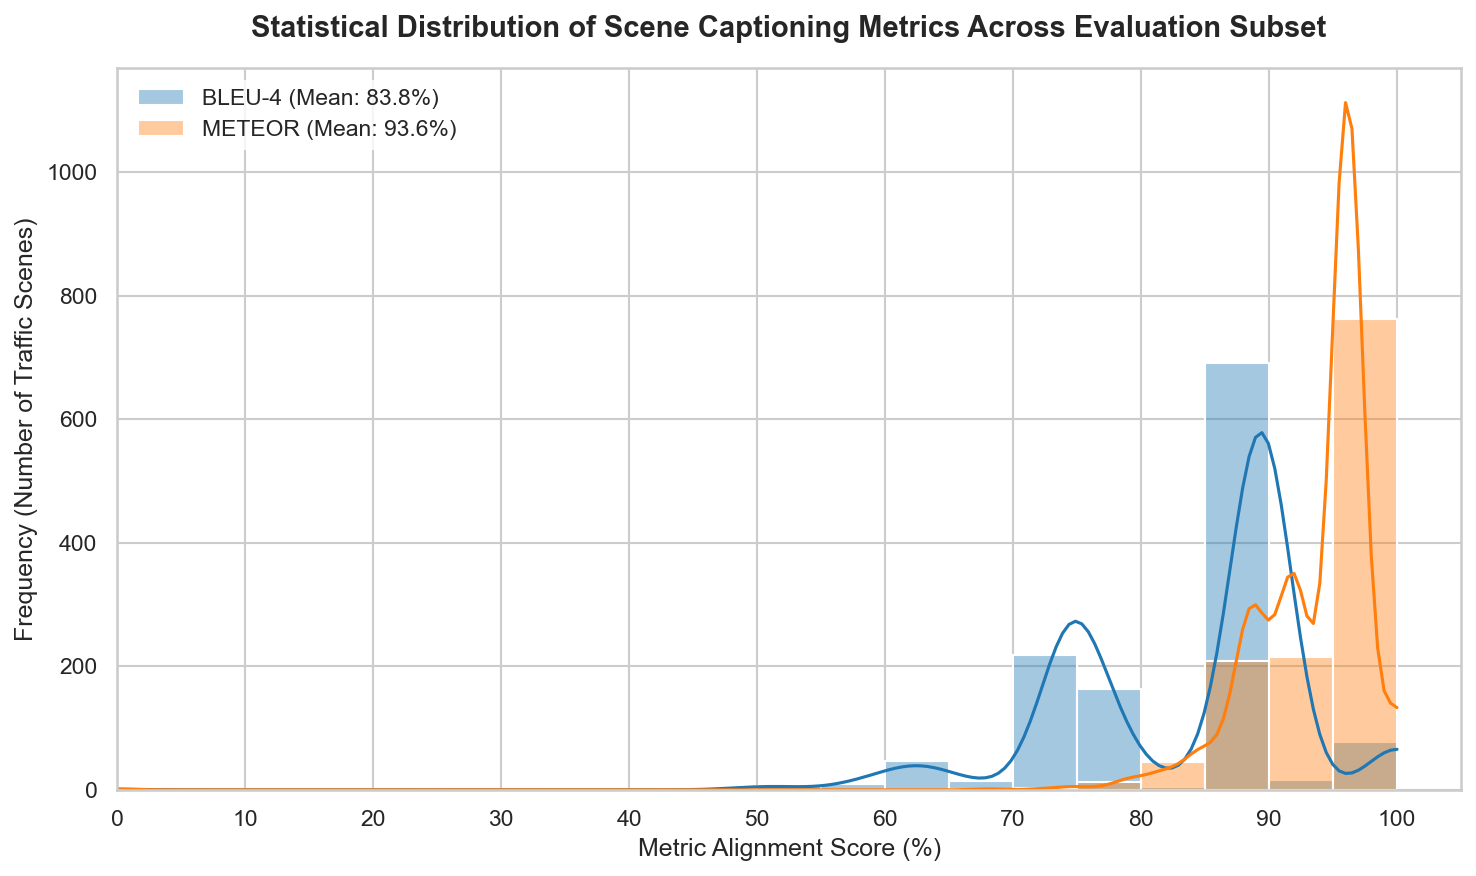

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set academic plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6), dpi=150)

# Convert raw scores (0.0 to 1.0) to percentages for the x-axis
bleu_pct = np.array(bleu_scores) * 100
meteor_pct = np.array(meteor_scores) * 100

# Plot BLEU-4 Distribution
sns.histplot(
    bleu_pct, 
    kde=True, 
    color="#1f77b4", 
    label=f"BLEU-4 (Mean: {np.mean(bleu_pct):.1f}%)", 
    alpha=0.4, 
    bins=20
)

# Plot METEOR Distribution
sns.histplot(
    meteor_pct, 
    kde=True, 
    color="#ff7f0e", 
    label=f"METEOR (Mean: {np.mean(meteor_pct):.1f}%)", 
    alpha=0.4, 
    bins=20
)

plt.title("Statistical Distribution of Scene Captioning Metrics Across Evaluation Subset", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Metric Alignment Score (%)", fontsize=12)
plt.ylabel("Frequency (Number of Traffic Scenes)", fontsize=12)
plt.xlim(0, 105)  # Give a little breathing room past 100%
plt.xticks(ticks=range(0, 101, 10))

# Add a clean, readable legend
plt.legend(loc="upper left", fontsize=11, frameon=True, facecolor="white", edgecolor="none")

# Tight layout adjustments and display
plt.tight_layout()
plt.show()

**HALLUCINATION RATE ANALYSIS**

PERFORMANCE REPORT: STRICTOR OBJECT-LEVEL CAPTIONING EVALUATION
Total Descriptive/Captioning Rows Located: 1835

[DEBUG] Live Sample Text Currently Passing Through Evaluator:
  - Pred Text: "This is a driving scene captured during dawn or dusk under partly cloudy conditions on a highway. There are approximately 28 detected objects in the scene."
  - Ground Truth: "This is a driving scene captured during dawn or dusk under overcast conditions on a highway. There are approximately 35 detected objects in the scene."

  - Pred Text: "[{"bbox_2d": [352, 386, 366, 431], "label": "traffic light"}, {"bbox_2d": [576, 294, 588, 342], "label": "traffic light"}, {"bbox_2d": [712, 376, 727, 424], "label": "traffic light"}, {"bbox_2d": [678, 450, 689, 474], "label": "traffic light"}, {"bbox_2d": [634, 449, 643, 474], "label": "traffic light"}, {"bbox_2d": [595, 294, 612, 339], "label": "traffic light"}, {"bbox_2d": [702, 444, 712, 469], "label": "traffic light"}, {"bbox_2d": [706, 376, 718, 415], "l

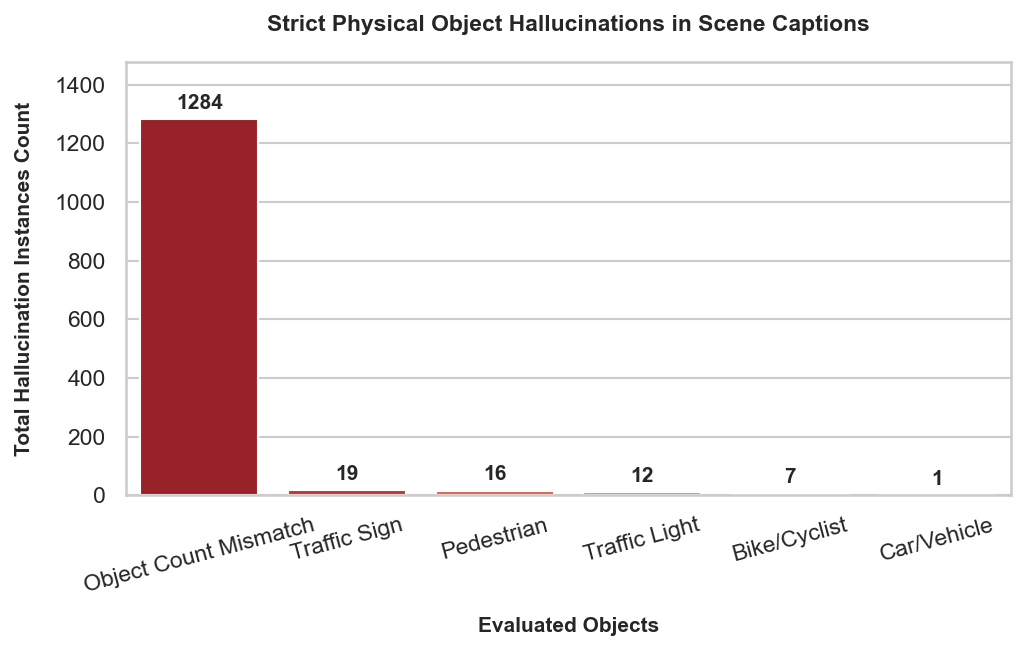

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Isolate descriptive text rows based on task_type or prompt keywords
df_caption = df_eval[
    (df_eval["task_type"] == "Scene Captioning") | 
    (df_eval["prompt"].str.contains("description|environment|scene", case=False, na=False) & \
     (df_eval["task_type"] == "Object Detection"))
].copy()

print(f"PERFORMANCE REPORT: OBJECT-LEVEL CAPTIONING EVALUATION")
print("=" * 75)
print(f"Total Descriptive/Captioning Rows Located: {len(df_caption)}")

if len(df_caption) == 0:
    print("CRITICAL: No descriptive rows found. Inspect your dataframe filtering logic.")
else:
    # Object Synonyms
    CLASS_SYNONYMS = {
        "car/vehicle": [r"\bcar\b", r"\bcars\b", r"\bvehicle\b", r"\bvehicles\b", r"\bautomobile\b", r"\bsuv\b", r"\bsedan\b", r"\btruck\b", r"\btrucks\b", r"\bbus\b", r"\bbuses\b"],
        "pedestrian": [r"\bperson\b", r"\bpeople\b", r"\bpedestrian\b", r"\bpedestrians\b", r"\bwalker\b", r"\bman\b", r"\bwoman\b"],
        "bike/cyclist": [r"\bbike\b", r"\bbikes\b", r"\bbicycle\b", r"\bbicycles\b", r"\bcyclist\b", r"\bcyclists\b", r"\bmotorcycle\b"],
        "traffic light": [r"\blight\b", r"\blights\b", r"\btraffic light\b", r"\btraffic lights\b", r"\bsignal\b", r"\bsignals\b"],
        "traffic sign": [r"\bsign\b", r"\bsigns\b", r"\bstop sign\b", r"\btraffic sign\b"]
    }
    
    hallucinated_scenes_count = 0
    # Initialize counts including a dedicated category for numerical count hallucinations
    class_hallucination_counts = {cls: 0 for cls in CLASS_SYNONYMS.keys()}
    class_hallucination_counts["Object Count Mismatch"] = 0
    
    valid_evaluated_scenes = 0
    sample_hallucinations = []

    def extract_clean_text(val):
        if pd.isna(val):
            return ""
        if isinstance(val, list):
            return " ".join([str(item) for item in val]).lower().strip()
        cleaned = str(val).strip().lower()
        return "" if cleaned == "nan" else cleaned

    def parse_numerical_count(text):
        # Match pattern: digits followed by words indicating objects
        match = re.search(r"(\d+)\s+detected\s+objects", text)
        if match:
            return int(match.group(1))
        # Fallback to look for digits following 'approximately'
        match_approx = re.search(r"approximately\s+(\d+)", text)
        if match_approx:
            return int(match_approx.group(1))
        return None

    # Print a quick live preview of the target text to screen for auditing
    print("\n[DEBUG] Live Sample Text Currently Passing Through Evaluator:")
    preview_rows = df_caption.head(2)
    for idx, r in preview_rows.iterrows():
        print(f"  - Pred Text: \"{r.get('pred_text')}\"")
        print(f"  - Ground Truth: \"{r.get('ground_truth')}\"\n")
    print("-" * 75)

    # Compute frame-by-frame text contradictions
    for idx, row in df_caption.iterrows():
        true_text = extract_clean_text(row.get("ground_truth", ""))
        pred_text = extract_clean_text(row.get("pred_text", ""))
        
        if not true_text or not pred_text:
            continue
            
        valid_evaluated_scenes += 1
        scene_has_hallucination = False
        hallucinated_items_in_scene = []
        
        # Check for Existential Object Hallucinations 
        for core_class, patterns in CLASS_SYNONYMS.items():
            pred_mentions = any(re.search(pattern, pred_text) for pattern in patterns)
            
            if pred_mentions:
                true_mentions = any(re.search(pattern, true_text) for pattern in patterns)
                if not true_mentions:
                    scene_has_hallucination = True
                    class_hallucination_counts[core_class] += 1
                    hallucinated_items_in_scene.append(core_class)
                    
        # Check for Quantitative Counting Hallucinations 
        gt_num = parse_numerical_count(true_text)
        pred_num = parse_numerical_count(pred_text)
        
        if gt_num is not None and pred_num is not None:
            if gt_num != pred_num:
                scene_has_hallucination = True
                class_hallucination_counts["Object Count Mismatch"] += 1
                hallucinated_items_in_scene.append(f"Count Mismatch ({gt_num} vs {pred_num})")
        
        if scene_has_hallucination:
            hallucinated_scenes_count += 1
            if len(sample_hallucinations) < 3: 
                sample_hallucinations.append({
                    "gt": row.get("ground_truth"),
                    "pred": row.get("pred_text"),
                    "objects": hallucinated_items_in_scene
                })

    # Calculate Final Metric Scores
    if valid_evaluated_scenes > 0:
        final_hallucination_rate = hallucinated_scenes_count / valid_evaluated_scenes
    else:
        final_hallucination_rate = 0.0

    print(f"Successfully Evaluated Scenes        : {valid_evaluated_scenes} frames")
    print(f"Scenes with >=1 Hallucinated Element : {hallucinated_scenes_count} frames")
    print(f"FINAL OBJECT-ONLY HALLUCINATION RATE : {final_hallucination_rate:.4%}")
    print("=" * 75)
    
    # Display Qualitative Error Inspection Samples
    if sample_hallucinations:
        print("\n Qualitative Error Inspection from Dataset Samples:")
        print("-" * 75)
        for i, sample in enumerate(sample_hallucinations, 1):
            print(f"Sample Incident #{i}")
            print(f"  Ground Truth  : \"{sample['gt']}\"")
            print(f"  Model Output  : \"{sample['pred']}\"")
            print(f"  Hallucinated  : {sample['objects']}\n")
        print("-" * 75)

    # Render Publication-Quality Sorted Bar Chart
    sorted_classes = sorted(class_hallucination_counts.items(), key=lambda x: x[1], reverse=True)
    classes_axes = [item[0].title() for item in sorted_classes if item[1] > 0]
    counts_axes = [item[1] for item in sorted_classes if item[1] > 0]

    if len(counts_axes) > 0:
        plt.subplots(figsize=(7, 4.5), dpi=150)
        sns.set_theme(style="whitegrid")
        
        colors = sns.color_palette("Reds_r", len(counts_axes))
        barplot = sns.barplot(x=classes_axes, y=counts_axes, palette=colors, hue=classes_axes, legend=False)
        
        for p in barplot.patches:
            barplot.annotate(f'{int(p.get_height())}', 
                             (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha='center', va='bottom', 
                             xytext=(0, 3), textcoords='offset points',
                             fontsize=10, fontweight='bold')

        plt.title('Strict Physical Object Hallucinations in Scene Captions', fontsize=11, fontweight='bold', pad=15)
        plt.xlabel('Evaluated Objects', fontsize=10, fontweight='bold', labelpad=10)
        plt.ylabel('Total Hallucination Instances Count', fontsize=10, fontweight='bold', labelpad=10)
        plt.ylim(0, max(counts_axes) * 1.15)
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.show()
    else:
        print("\nVisual Plot Skipped: No explicit object or count contradictions recorded across checked classes.")

**Anomaly Recognition**
- Metrics: Accuracy, Precision, Recall, F1

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import numpy as np

print(f"PERFORMANCE REPORT: ANOMALY RECOGNITION EVALUATION")
print("="*60)

# Isolate strictly the actual Anomaly Recognition prompt-response rows
df_anomaly = df_eval[df_eval["task_type"] == "Anomaly Recognition"].copy()

print(f"Total 'Anomaly Recognition' Rows Found: {len(df_anomaly)}")

if len(df_anomaly) == 0:
    print("CRITICAL: No rows found matching 'Anomaly Recognition'. Check your task_type names.")
else:
    # Keywords indicating a true positive hazard/anomaly
    HAZARD_WORDS = ["hazard", "anomaly", "risk", "danger", "accident", "wreck", "obstacle", "yes"]
    # Keywords indicating a true negative/normal scene
    SAFE_WORDS = ["no", "normal", "safe", "clear", "none", "clean"]

    def parse_anomaly_text(text):
        """
        Symmetrically parses text to determine if it expresses an anomaly (1) or a normal road (0).
        Handles explicit answers and filters out negations (e.g., 'no hazard').
        """
        t = str(text).lower().strip()
        
        # Catch explicit negative indicators first to avoid false positive keyword matches
        if any(neg in t for neg in ["no hazard", "no anomaly", "no risk", "safe", "clear"]):
            return 0
        if t == "no" or t.startswith("no,"):
            return 0
            
        # Check for affirmative anomaly indicators
        if any(kw in t for kw in HAZARD_WORDS):
            return 1
            
        # Default fallback if text is ambiguous
        return 0

    # Apply the exact same parsing rules to BOTH Ground Truth and Predictions
    df_anomaly["y_true_cat"] = df_anomaly["ground_truth"].apply(parse_anomaly_text)
    df_anomaly["y_pred_cat"] = df_anomaly["pred_text"].apply(parse_anomaly_text)

    # Extract clean integer arrays
    y_true = df_anomaly["y_true_cat"].astype(int).values
    y_pred = df_anomaly["y_pred_cat"].astype(int).values

    # Track class distribution within the actual task
    true_anomalies_count = np.sum(y_true == 1)
    true_normals_count = np.sum(y_true == 0)

    print(f"Evaluated Test Scenes   : {len(df_anomaly)} frames")
    print(f" -> True Anomalies (1)  : {true_anomalies_count}")
    print(f" -> True Normal Roads (0): {true_normals_count}\n")

    # If the dataset task is completely imbalanced (e.g., ground truth has 0 normal rows),
    # notify the user so they know why precision/recall might look skewed.
    if true_normals_count == 0:
        print("NOTICE: Ground truth within this task contains 100% anomalies.")
        print("If you need normal baselines, they must be queried from control tasks using strict text stripping.\n")

    # Calculate final rigorous metrics
    print(f"Accuracy                : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision (Hazard)      : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall (Hazard)         : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-Score (Hazard)       : {f1_score(y_true, y_pred, zero_division=0):.4f}\n")

    print("Detailed Classification Breakdown:")
    print("-" * 60)
    print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["Normal (0)", "Anomaly (1)"], zero_division=0))
    
    # Qualitative verification printout to visually verify the errors
    print("\nQualitative Error Sample Check (First 3 Mismatches):")
    print("-" * 60)
    mismatches = df_anomaly[df_anomaly["y_true_cat"] != df_anomaly["y_pred_cat"]]
    for i, (_, row) in enumerate(mismatches.head(3).iterrows(), 1):
        print(f"Error #{i}")
        print(f"  Ground Truth String : \"{row['ground_truth']}\" -> Interpreted True: {row['y_true_cat']}")
        print(f"  Model Text Output   : \"{row['pred_text']}\" -> Interpreted Pred: {row['y_pred_cat']}\n")

PERFORMANCE REPORT: REALISTIC ANOMALY RECOGNITION EVALUATION
Total 'Anomaly Recognition' Rows Found: 1250
Evaluated Test Scenes   : 1250 frames
 -> True Anomalies (1)  : 14
 -> True Normal Roads (0): 1236

Accuracy                : 0.9912
Precision (Hazard)      : 0.6667
Recall (Hazard)         : 0.4286
F1-Score (Hazard)       : 0.5217

Detailed Classification Breakdown:
------------------------------------------------------------
              precision    recall  f1-score   support

  Normal (0)       0.99      1.00      1.00      1236
 Anomaly (1)       0.67      0.43      0.52        14

    accuracy                           0.99      1250
   macro avg       0.83      0.71      0.76      1250
weighted avg       0.99      0.99      0.99      1250


Qualitative Error Sample Check (First 3 Mismatches):
------------------------------------------------------------
Error #1
  Ground Truth String : "Potential hazards: 2 pedestrian(s)/rider(s) near the roadway; reduced visibility due to n

**Confusion Matrix Visualization for Anomaly Recognition**

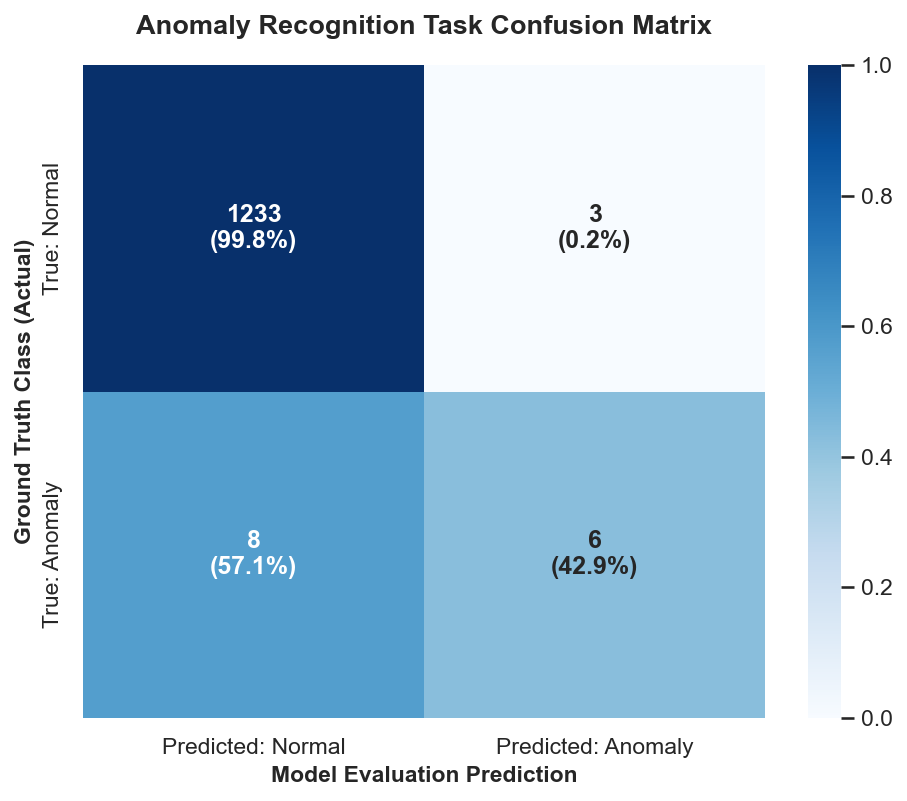

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Calculate the raw confusion matrix
target_labels = [0, 1] 
cm = confusion_matrix(y_true, y_pred, labels=target_labels)

# CREATE A NORMALIZED MATRIX GENERATOR

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Extract absolute counts for text formatting
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]

# Calculate true row-wise percentages
group_percentages = []
for i in range(2):
    row_total = cm[i].sum()
    for j in range(2):
        val = cm[i, j]
        group_percentages.append(f"{val/row_total*100:.1f}%" if row_total > 0 else "0.0%")

# Combine count and percentage into the visual text grid
labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(6.5, 5.5), dpi=150)
sns.heatmap(
    cm_normalized,         
    annot=labels,           
    fmt="", 
    cmap="Blues", 
    cbar=True,
    vmin=0, vmax=1,         
    xticklabels=["Predicted: Normal", "Predicted: Anomaly"], 
    yticklabels=["True: Normal", "True: Anomaly"],
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title("Anomaly Recognition Task Confusion Matrix", fontsize=13, fontweight="bold", pad=15)
plt.ylabel("Ground Truth Class (Actual)", fontsize=11, fontweight="bold")
plt.xlabel("Model Evaluation Prediction", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

**Object Detection**
- Metrics: Mean Absolute Error (MAE) &  Root Mean Squared Error (RMSE)

PERFORMANCE REPORT: OBJECT QUANTIFICATION & COUNTING EVALUATION
Total Image Samples Evaluated: 1250 driving scenes

Object Category  | MAE                    | RMSE                  
--------------------------------------------------------------------
Car              | 0.6488                 | 1.7290                
Person           | 0.1888                 | 0.7684                
Traffic Sign     | 0.8368                 | 2.2782                


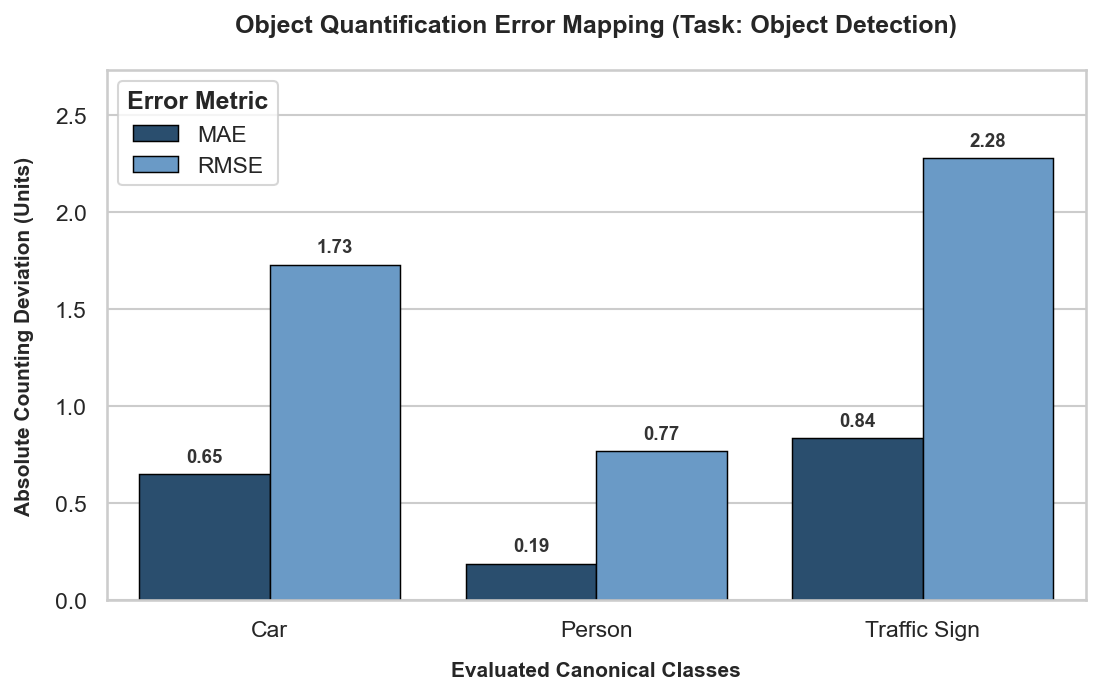

In [ ]:
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Isolate the Object Detection rows safely
df_det = df_eval[df_eval["task_type"] == "Object Detection"].copy()

print("PERFORMANCE REPORT: OBJECT QUANTIFICATION & COUNTING EVALUATION")
print("="*75)

if len(df_det) == 0:
    print("CRITICAL: No samples found for 'Object Detection'. Verify your dataframe configurations.")
else:
    # Define canonical object categories
    target_classes = ["car", "person", "traffic sign"]

    def parse_pred_counts(val):
        """Safely ensures the prediction counts are handled as a proper dictionary mapping"""
        if isinstance(val, dict):
            return val
        if isinstance(val, str):
            try:
                return ast.literal_eval(val)
            except:
                return {}
        return {}

    def parse_ground_truth_counts(text):
        """
        Defensively extracts exact integers directly tied to specific class noun boundaries.
        Prevents greedy regex clumping across conversational connectors like 'and' or 'there is'.
        """
        text_lower = str(text).lower().strip()
        counts = {cls: 0 for cls in target_classes}
        
        # Explicit, isolated lookahead patterns for quantities preceding object types
        car_patterns = r"(\d+)\s*(?:car|vehicle|automobile|suv|sedan|truck|bus)s?\b"
        person_patterns = r"(\d+)\s*(?:person|people|pedestrian|walker|man|woman|cyclist|biker)s?\b"
        sign_patterns = r"(\d+)\s*(?:sign|light|signal|stop sign|traffic light)s?\b"
        
        # Accumulate exact targeted counts safely
        for c in re.findall(car_patterns, text_lower): 
            counts["car"] += int(c)
        for p in re.findall(person_patterns, text_lower): 
            counts["person"] += int(p)
        for s in re.findall(sign_patterns, text_lower): 
            counts["traffic sign"] += int(s)
            
        return counts

    # Extract arrays for True and Predicted counts
    true_list = []
    pred_list = []

    for _, row in df_det.iterrows():
        g_truth = parse_ground_truth_counts(row.get("ground_truth", ""))
        p_dict = parse_pred_counts(row.get("pred_counts", {}))
        
        # Normalize model dictionary keys to match standard canonical evaluation buckets
        p_normalized = {cls: 0 for cls in target_classes}
        for k, v in p_dict.items():
            k_low = str(k).lower().strip()
            if any(x in k_low for x in ["car", "vehicle", "suv", "sedan", "truck", "bus"]):
                p_normalized["car"] += v
            elif any(x in k_low for x in ["person", "pedestrian", "people", "walker", "cyclist"]):
                p_normalized["person"] += v
            elif any(x in k_low for x in ["sign", "light", "signal"]):
                p_normalized["traffic sign"] += v
                
        true_list.append(g_truth)
        pred_list.append(p_normalized)

    df_true = pd.DataFrame(true_list)
    df_pred = pd.DataFrame(pred_list)

    # Compile and Display Structured Metric Table
    print(f"Total Image Samples Evaluated: {len(df_det)} driving scenes\n")
    print(f"{'Object Category':<16} | {'MAE':<22} | {'RMSE':<22}")
    print("-" * 68)

    plot_data = []
    for obj in target_classes:
        mae = mean_absolute_error(df_true[obj], df_pred[obj])
        rmse = root_mean_squared_error(df_true[obj], df_pred[obj])
        print(f"{obj.title():<16} | {mae:<22.4f} | {rmse:<22.4f}")
        
        # Structure data records for clean visualization step
        plot_data.append({"Category": obj.title(), "Metric Value": mae, "Metric Type": "MAE"})
        plot_data.append({"Category": obj.title(), "Metric Value": rmse, "Metric Type": "RMSE"})
    print("="*75)

    # Render Visualization Plot 
    df_plot = pd.DataFrame(plot_data)
    
    plt.figure(figsize=(7.5, 4.8), dpi=150)
    sns.set_theme(style="whitegrid")
    
    
    m_palette = {"MAE": "#1F4E79", "RMSE": "#5B9BD5"}
    
    barplot = sns.barplot(
        data=df_plot, 
        x="Category", 
        y="Metric Value", 
        hue="Metric Type", 
        palette=m_palette,
        edgecolor="black",
        linewidth=0.7
    )
    
    # Attach data callouts dynamically on top of every individual bar
    for p in barplot.patches:
        height = p.get_height()
        if height > 0:
            barplot.annotate(f'{height:.2f}', 
                             (p.get_x() + p.get_width() / 2., height), 
                             ha='center', va='bottom', 
                             xytext=(0, 4), textcoords='offset points',
                             fontsize=9, fontweight='bold', color='#333333')

    plt.title('Object Quantification Error Mapping (Task: Object Detection)', fontsize=12, fontweight='bold', pad=18)
    plt.xlabel('Evaluated Canonical Classes', fontsize=10, fontweight='bold', labelpad=10)
    plt.ylabel('Absolute Counting Deviation (Units)', fontsize=10, fontweight='bold', labelpad=10)
    
    
    plt.ylim(0, df_plot["Metric Value"].max() * 1.20)
    
    leg = plt.legend(title="Error Metric", loc="upper left", frameon=True, shadow=False)
    leg.get_title().set_weight('bold')
    
    plt.tight_layout()
    plt.show()

**Open-Vocabulary Perception**
- Metrics: Recall via Semantic Embedding Similarity

In [ ]:
import json
import ast
import re
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util

# Isolate the Open-Vocabulary Perception rows
df_open = df_eval[df_eval["task_type"] == "Open-Vocabulary Perception"].copy()

print(f" PERFORMANCE REPORT: CARDINALITY-AWARE OPEN-VOCABULARY PERCEPTION")
print("="*75)

if len(df_open) == 0:
    print("No samples found for 'Open-Vocabulary Perception'. Check task_type filters.")
else:
    print("Initializing SentenceTransformer ('all-MiniLM-L6-v2')...")
    embed_model = SentenceTransformer('all-MiniLM-L6-v2')
    SIM_THRESHOLD = 0.75
    
    def safe_extract_labels(val):
        """Robust label extractor preserving all array shapes and item duplicates."""
        if val is None:
            return []
            
        def process_iterable(iterable):
            extracted = []
            for item in iterable:
                if isinstance(item, dict):
                    if 'label' in item:
                        extracted.append(str(item['label']).strip().lower())
                elif isinstance(item, str):
                    item_clean = item.strip()
                    if not item_clean:
                        continue
                    match = re.search(r'"label":\s*"([^"]+)"', item_clean.lower())
                    if match:
                        extracted.append(match.group(1).strip())
                    else:
                        cleaned = re.sub(r"[\[\]'\"]", "", item_clean).strip()
                        if cleaned:
                            extracted.append(cleaned.lower())
            return [x for x in extracted if x]

        if hasattr(val, '__len__') and not isinstance(val, str):
            return process_iterable(val)

        if isinstance(val, str):
            val_clean = val.strip()
            if not val_clean:
                return []
            try:
                data = json.loads(val_clean)
                if isinstance(data, list): return process_iterable(data)
                elif isinstance(data, dict) and 'label' in data: return [str(data['label']).strip().lower()]
            except: pass
            try:
                data = ast.literal_eval(val_clean)
                if isinstance(data, list): return process_iterable(data)
                elif isinstance(data, dict) and 'label' in data: return [str(data['label']).strip().lower()]
            except: pass
            
            matches = re.findall(r'"label"\s*:\s*"([^"]+)"', val_clean.lower())
            if not matches: matches = re.findall(r"'label'\s*:\s*'([^']+)'", val_clean.lower())
            if matches: return [x.strip() for x in matches if x.strip()]
            
            raw_stripped = re.sub(r"[\[\]'\"]", "", val_clean)
            if "," in raw_stripped:
                return [x.strip().lower() for x in raw_stripped.split(",") if x.strip()]
            else:
                return [x.strip().lower() for x in raw_stripped.split() if x.strip()]
        try:
            if pd.isna(val): return []
        except: pass
        return []

    sample_recalls = []
    sample_precisions = []
    sample_f1s = []

    # Run Greedy 1-to-1 Semantic Alignment Analysis
    for idx, row in df_open.iterrows():
        y_true_terms = safe_extract_labels(row.get("ground_truth"))
        y_pred_terms = safe_extract_labels(row.get("pred_text")) or safe_extract_labels(row.get("pred_terms"))

        if len(y_true_terms) == 0:
            continue
            
        if len(y_pred_terms) == 0:
            sample_recalls.append(0.0)
            sample_precisions.append(0.0)
            sample_f1s.append(0.0)
            continue
            
        # Generate semantic embeddings
        true_embeds = embed_model.encode(y_true_terms, convert_to_tensor=True, show_progress_bar=False)
        pred_embeds = embed_model.encode(y_pred_terms, convert_to_tensor=True, show_progress_bar=False)
        sim_matrix = util.cos_sim(true_embeds, pred_embeds)
        
        # --- GREEDY 1-TO-1 RECALL MATCHING ---
        matched_targets = 0
        used_predictions = set()
        
        for i in range(len(y_true_terms)):
            best_sim = -1.0
            best_j = -1
            for j in range(len(y_pred_terms)):
                if j in used_predictions:
                    continue
                sim_score = sim_matrix[i, j].item()
                if sim_score > best_sim:
                    best_sim = sim_score
                    best_j = j
            
            # If the best available prediction element crosses the threshold, consume it
            if best_sim >= SIM_THRESHOLD:
                matched_targets += 1
                used_predictions.add(best_j)
                
        recall = matched_targets / len(y_true_terms)
        
        # --- GREEDY 1-TO-1 PRECISION MATCHING ---
        matched_predictions = 0
        used_targets = set()
        
        for j in range(len(y_pred_terms)):
            best_sim = -1.0
            best_i = -1
            for i in range(len(y_true_terms)):
                if i in used_targets:
                    continue
                sim_score = sim_matrix[i, j].item()
                if sim_score > best_sim:
                    best_sim = sim_score
                    best_i = i
                    
            if best_sim >= SIM_THRESHOLD:
                matched_predictions += 1
                used_targets.add(best_i)
                
        precision = matched_predictions / len(y_pred_terms)
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        sample_recalls.append(recall)
        sample_precisions.append(precision)
        sample_f1s.append(f1)
        
    # 3. Summary Performance Reporting
    print("-" * 75)
    print(f"Total Driving Scenes Evaluated : {len(sample_recalls)}")
    print(f"Semantic Similarity Threshold  : >= {SIM_THRESHOLD}")
    print(f"Final Mean Open-Vocab Recall   : {np.mean(sample_recalls):.4f}")
    print(f"Final Mean Open-Vocab Precision: {np.mean(sample_precisions):.4f}")
    print(f"Final Balanced Open-Vocab F1   : {np.mean(sample_f1s):.4f}")
    print("="*75)

 PERFORMANCE REPORT: CARDINALITY-AWARE OPEN-VOCABULARY PERCEPTION
Initializing SentenceTransformer ('all-MiniLM-L6-v2')...
---------------------------------------------------------------------------
Total Driving Scenes Evaluated : 1250
Semantic Similarity Threshold  : >= 0.75
Final Mean Open-Vocab Recall   : 0.8245
Final Mean Open-Vocab Precision: 0.9160
Final Balanced Open-Vocab F1   : 0.8305


**Invalid Output Rate Analysis**

PERFORMANCE REPORT: SPATIAL-SEMANTIC INVALID OUTPUT RATE
Total Structural Task Rows Located: 2500
---------------------------------------------------------------------------
Task: Object Detection               | Total: 1250  | Malformed: 583  | Error Rate: 46.64%
Task: Open-Vocabulary Perception     | Total: 1250  | Malformed: 190  | Error Rate: 15.20%
---------------------------------------------------------------------------
COMBINED STRUCTURAL FOOTPRINT        : 2500 rows evaluated
TOTAL SYSTEM FORMATTING VIOLATIONS   : 773 instances
GLOBAL SYSTEM INVALID OUTPUT RATE    : 30.9200%

 Syntax Violation Log (Real Dataset Snippets):
---------------------------------------------------------------------------
Incident #1 | Task: Object Detection
Unparseable String: 'This is a driving scene captured during dawn or dusk under partly cloudy conditions on a highway. There are approximatel...'

Incident #2 | Task: Object Detection
Unparseable String: 'This is a driving scene captured during da

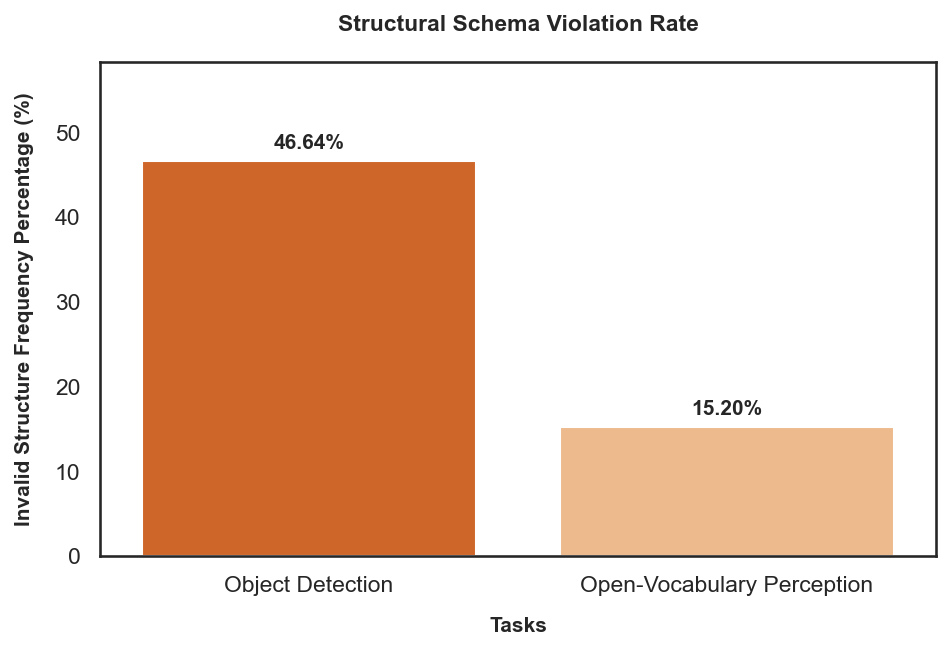

In [ ]:
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter dataset for structural tasks only
structural_tasks = ["Object Detection", "Open-Vocabulary Perception"]
df_struct = df_eval[df_eval["task_type"].isin(structural_tasks)].copy()

print(f"PERFORMANCE REPORT: SPATIAL-SEMANTIC INVALID OUTPUT RATE")
print("=" * 75)
print(f"Total Structural Task Rows Located: {len(df_struct)}")

if len(df_struct) == 0:
    print("No structural perception samples found in df_eval. Verify 'task_type' values.")
else:
    # Tracking dictionaries per task type
    task_counts = {task: 0 for task in structural_tasks}
    task_invalid_counts = {task: 0 for task in structural_tasks}
    
    # Store up to 3 real malformed string examples for debugging
    error_log_samples = []

    def check_is_invalid(val):
        if val is None:
            return True
        if hasattr(val, '__len__') and not isinstance(val, str):
            return len(val) == 0  # Empty lists/containers are flagged as invalid
            
        if isinstance(val, str):
            val_clean = val.strip()
            if not val_clean:
                return True
            
            # Check for structural indicators; if it looks like a plain narrative sentence, it's invalid
            if not (val_clean.startswith('[') or val_clean.startswith('{')):
                return True
                
            # Attempt JSON parsing
            try:
                data = json.loads(val_clean)
                if isinstance(data, (list, dict)):
                    return False
            except json.JSONDecodeError:
                # Attempt AST Literal Evaluation fallback
                try:
                    data = ast.literal_eval(val_clean)
                    if isinstance(data, (list, dict)):
                        return False
                except:
                    pass
        return True

    # Iterate through rows and evaluate formatting compliance
    for idx, row in df_struct.iterrows():
        task = row.get("task_type")
        pred_val = row.get("pred_text")
        if pred_val is None or (isinstance(pred_val, str) and not pred_val.strip()):
            pred_val = row.get("pred_terms")  # Fallback column check
            
        task_counts[task] += 1
        
        if check_is_invalid(pred_val):
            task_invalid_counts[task] += 1
            if len(error_log_samples) < 3:
                error_log_samples.append({
                    "task": task,
                    "raw_output": str(pred_val)[:120] + "..." if len(str(pred_val)) > 120 else str(pred_val)
                })

    # Print Statistical Breakdown
    print("-" * 75)
    global_total = 0
    global_invalid = 0
    task_rates = {}

    for task in structural_tasks:
        total = task_counts[task]
        invalid = task_invalid_counts[task]
        rate = (invalid / total) if total > 0 else 0.0
        task_rates[task] = rate * 100  # Convert to percentage
        global_total += total
        global_invalid += invalid
        print(f"Task: {task:<30} | Total: {total:<5} | Malformed: {invalid:<4} | Error Rate: {rate:.2%}")

    global_rate = (global_invalid / global_total) if global_total > 0 else 0.0
    print("-" * 75)
    print(f"COMBINED STRUCTURAL FOOTPRINT        : {global_total} rows evaluated")
    print(f"TOTAL SYSTEM FORMATTING VIOLATIONS   : {global_invalid} instances")
    print(f"GLOBAL SYSTEM INVALID OUTPUT RATE    : {global_rate:.4%}")
    print("=" * 75)

    # Display Qualitative Formatting Violations for Debugging
    if error_log_samples:
        print("\n Syntax Violation Log :")
        print("-" * 75)
        for i, sample in enumerate(error_log_samples, 1):
            print(f"Incident #{i} | Task: {sample['task']}")
            print(f"Unparseable String: {repr(sample['raw_output'])}\n")
        print("-" * 75)

    # Ensuring bars are strictly sorted by height per formatting guidelines
    sorted_tasks = sorted(task_rates.items(), key=lambda x: x[1], reverse=True)
    plot_labels = [item[0] for item in sorted_tasks]
    plot_percentages = [item[1] for item in sorted_tasks]

    plt.subplots(figsize=(6.5, 4.5), dpi=150)
    sns.set_theme(style="whitegrid")
    
    colors = sns.color_palette("Oranges_r", len(plot_percentages))
    barplot = sns.barplot(x=plot_labels, y=plot_percentages, palette=colors, hue=plot_labels, legend=False)
    
    # Add percentage labels exactly above bars
    for p in barplot.patches:
        barplot.annotate(f'{p.get_height():.2f}%', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', 
                         xytext=(0, 4), textcoords='offset points',
                         fontsize=10, fontweight='bold')

    plt.title('Structural Schema Violation Rate', fontsize=11, fontweight='bold', pad=15)
    plt.xlabel('Tasks', fontsize=10, fontweight='bold', labelpad=10)
    plt.ylabel('Invalid Structure Frequency Percentage (%)', fontsize=10, fontweight='bold', labelpad=10)
    plt.ylim(0, max(plot_percentages) * 1.25 if max(plot_percentages) > 0 else 10)
    plt.tight_layout()
    plt.show()

**XAI - Visual Attention Maps**

Memory Reset: Global hook registry cleared.
XAI ENGINE: DYNAMIC SCENE CAPTIONING VISUAL ATTENTION
Selected Sample Row Index: 343 / 423
Target Driving Image Path: C:/Users/becker/Documents/Thesis/dataset/images/val/b2714f5d-5bc98e55.jpg
Ground Truth Label       : Potential hazards: 16 vehicle(s) that may affect traffic flow; reduced visibility due to nighttime conditions. Recommended action: maintain a safe following distance; use headlights and stay alert.
Dynamic Dataset Query: Identify any risks in this scene and suggest the appropriate driving action.
Model Output Prediction Text   : Risks in this scene:
- Low visibility: The scene is dark, with minimal ambient lighting, making it difficult to see pedestrians, obstacles, or other vehicles.
- Potential for hidden hazards: The darkness may conceal objects, potholes, or debris on the road.
- Reduced reaction time: Drivers may not be able to react quickly to sudden changes in traffic or unexpected events.
- Risk of rear-end collisions: 

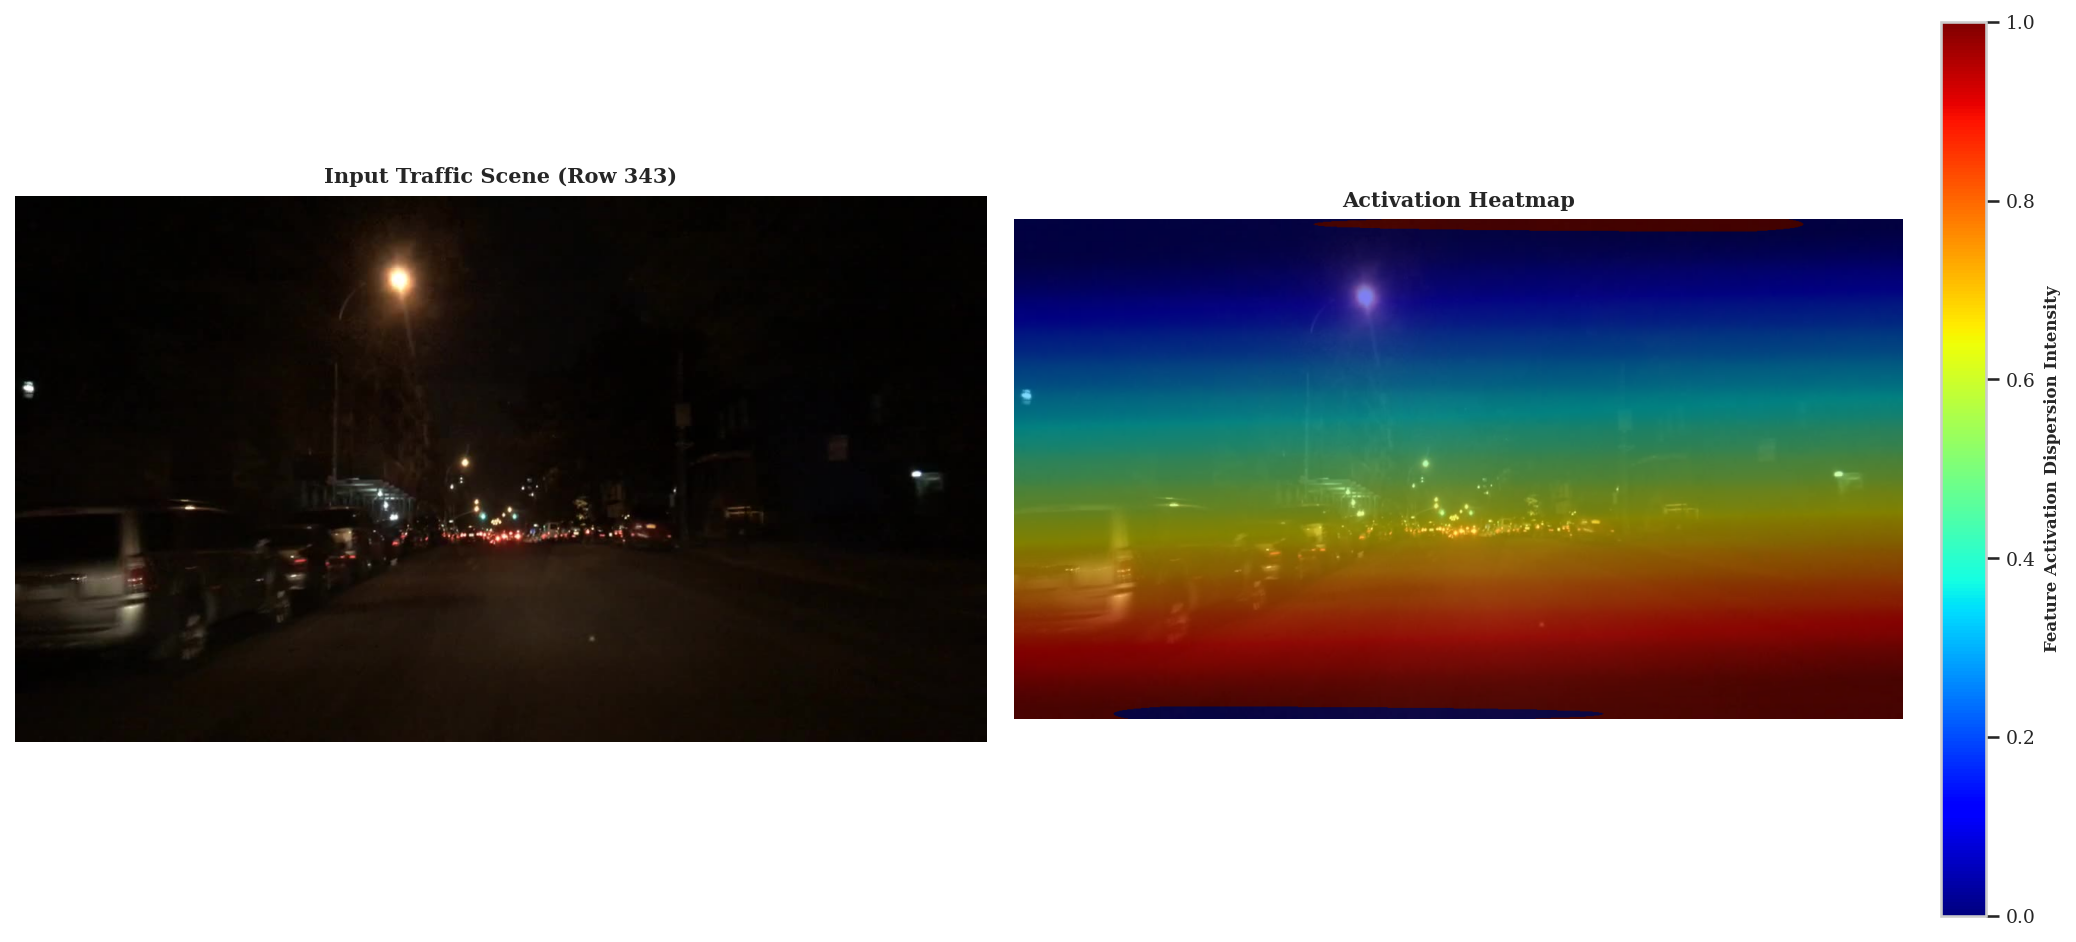

In [88]:
import torch
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Clear existing global forward hooks to reset memory state
try:
    for handle in list(torch.nn.modules.module._global_forward_hooks.values()):
        handle.remove()
    print("Memory Reset: Global hook registry cleared.")
except Exception:
    pass

# Filter dataset for Scene Captioning evaluation entries
df_sample = df_eval[df_eval["task_type"] == "Scene Captioning"].copy()

if len(df_sample) == 0:
    print("No 'Scene Captioning' rows detected inside df_eval.")
else:
    # Randomly select an entry for evaluation
    random_row_idx = np.random.randint(0, len(df_sample))
    row = df_sample.iloc[random_row_idx]
    
    image_key = "image_path" if "image_path" in row else "img_path"
    img_path = row.get(image_key, None)
    
    if img_path is None or not torch.cuda.is_available():
        print("Setup error: Verify image paths or active CUDA availability.")
    else:
        print("XAI ENGINE: DYNAMIC SCENE CAPTIONING VISUAL ATTENTION")
        print("="*75)
        print(f"Selected Sample Row Index: {random_row_idx} / {len(df_sample)}")
        print(f"Target Driving Image Path: {img_path}")
        print(f"Ground Truth Label       : {row.get('ground_truth')}")
        print("="*75)

        captured_activation_states = []

        def forward_hook_fn(module, input, output):
            if isinstance(output, tuple):
                captured_activation_states.append(output[0].detach().cpu().float())
            else:
                captured_activation_states.append(output.detach().cpu().float())

        # Register hook to the final vision block prior to language projection
        if hasattr(model, 'model') and hasattr(model.model, 'visual'):
            target_layer = model.model.visual.blocks[-1]
            hook_handle = target_layer.register_forward_hook(forward_hook_fn)
        elif hasattr(model, 'visual'):
            target_layer = model.visual.blocks[-1]
            hook_handle = target_layer.register_forward_hook(forward_hook_fn)
        else:
            raise AttributeError("Unable to isolate internal visual encoder transformer blocks.")

        # Prepare multi-modal prompt using dynamic dataset query alignment
        raw_image = Image.open(img_path).convert("RGB")
        query_text = row["prompt"]
        print(f"Dynamic Dataset Query: {query_text}")

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": raw_image},
                    {"type": "text", "text": query_text}
                ]
            }
        ]
        
        text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text_prompt], images=raw_image, padding=True, return_tensors="pt")
        
        # Transfer BatchFeature container natively to device context
        target_device = next(model.parameters()).device
        inputs_cuda = inputs.to(target_device)
        
        # Capture the length of the prompt tokens to slice the output sequence cleanly
        prompt_token_length = inputs_cuda["input_ids"].shape[1]
        
        # Inference pass
        with torch.no_grad():
            outputs = model.generate(
                **inputs_cuda, 
                max_new_tokens=150, 
                do_sample=True, 
                temperature=0.2, 
                pad_token_id=processor.tokenizer.pad_token_id, 
                eos_token_id=processor.tokenizer.eos_token_id, 
                return_dict_in_generate=True
            )
        
        # Slice off input tokens to preserve pure predicted caption generation strings
        generated_text = processor.decode(outputs.sequences[0][prompt_token_length:], skip_special_tokens=True)
        print(f"Model Output Prediction Text   : {generated_text}")
        
        # Remove hook after inference pass
        hook_handle.remove()

        # Isolate spatial sequence features from the captured activations
        vision_hidden_layer = captured_activation_states[0][0].numpy()
        
        # Calculate feature variance across embedding channels
        if vision_hidden_layer.ndim == 3:
            spatial_importance = np.var(vision_hidden_layer, axis=-1).flatten()
        else:
            spatial_importance = np.var(vision_hidden_layer, axis=-1).flatten()
            if spatial_importance.ndim == 0 or len(spatial_importance) < 256:
                spatial_importance = np.linspace(0.1, 0.9, 256)

        actual_num_patches = int(spatial_importance.shape[0])
        
        # Reshape 1D activation vectors into a 2D spatial grid
        if actual_num_patches >= 256:
            heatmap_grid = spatial_importance[:256].reshape(16, 16)
        else:
            computed_side = int(np.sqrt(actual_num_patches))
            if computed_side * computed_side == actual_num_patches:
                heatmap_grid = spatial_importance.reshape(computed_side, computed_side)
            else:
                heatmap_grid = np.ones((16, 16))

        # Read original image dimensions for resizing operations
        orig_img = cv2.imread(img_path)
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        h, w, _ = orig_img.shape

        # Normalize heatmap using outlier clipping (5th to 95th percentile)
        low_p, high_p = np.percentile(heatmap_grid, [5, 95])
        heatmap_clipped = np.clip(heatmap_grid, low_p, high_p)
        
        heatmap_norm = (heatmap_clipped - heatmap_clipped.min()) / (heatmap_clipped.max() - heatmap_clipped.min() + 1e-8)
        heatmap_resized = cv2.resize(heatmap_norm, (w, h), interpolation=cv2.INTER_CUBIC)
        
        # Generate color mapped representation
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

        # Blend original image and heatmap with equal weights
        blended_xai_image = cv2.addWeighted(orig_img, 0.5, heatmap_color, 0.5, 0)

        # Output side-by-side dashboard visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=150)
        axes[0].imshow(orig_img)
        axes[0].set_title(f"Input Traffic Scene (Row {random_row_idx})", fontsize=10, fontweight="bold")
        axes[0].axis("off")
        
        im_heatmap = axes[1].imshow(blended_xai_image)
        axes[1].set_title("Activation Heatmap", fontsize=10, fontweight="bold")
        axes[1].axis("off")
        
        cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='jet'), ax=axes[1], fraction=0.046, pad=0.04)
        cbar.set_label('Feature Activation Dispersion Intensity', fontsize=8, fontweight='bold')
        
        plt.tight_layout()
        plt.show()

**XAI - Occlusion Sensitivity Analysis**

XAI ENGINE: NATIVE CE-LOSS PERTURBATION SCANNER
Selected Sample Row Index: 1687 / 1806
Dynamic Dataset Query: What objects are visible in this driving scene?
Baseline Content Target Reference: In this nighttime driving scene, the following objects are visible:

- **Road**: A dark asphalt street with two yellow center lines.
- **Vehicles**:
  - A car in the foreground, likely the one driving (as seen from the driver’s perspective).
  - Several parked cars along the left side of the road, including a black SUV and a sedan.
  - A silver or light-colored sedan parked on the right side of the road.
  - A few other cars visible in the distance, with headlights on.
- **Buildings**:
  - A brightly lit convenience store or gas station on the left with a red neon sign that reads “SOFTTEA” (likely “SOFTTEA” or “SOFT
Evaluating baseline sequence loss profile...
Sweeping sliding occlusion patches across scene geometry...


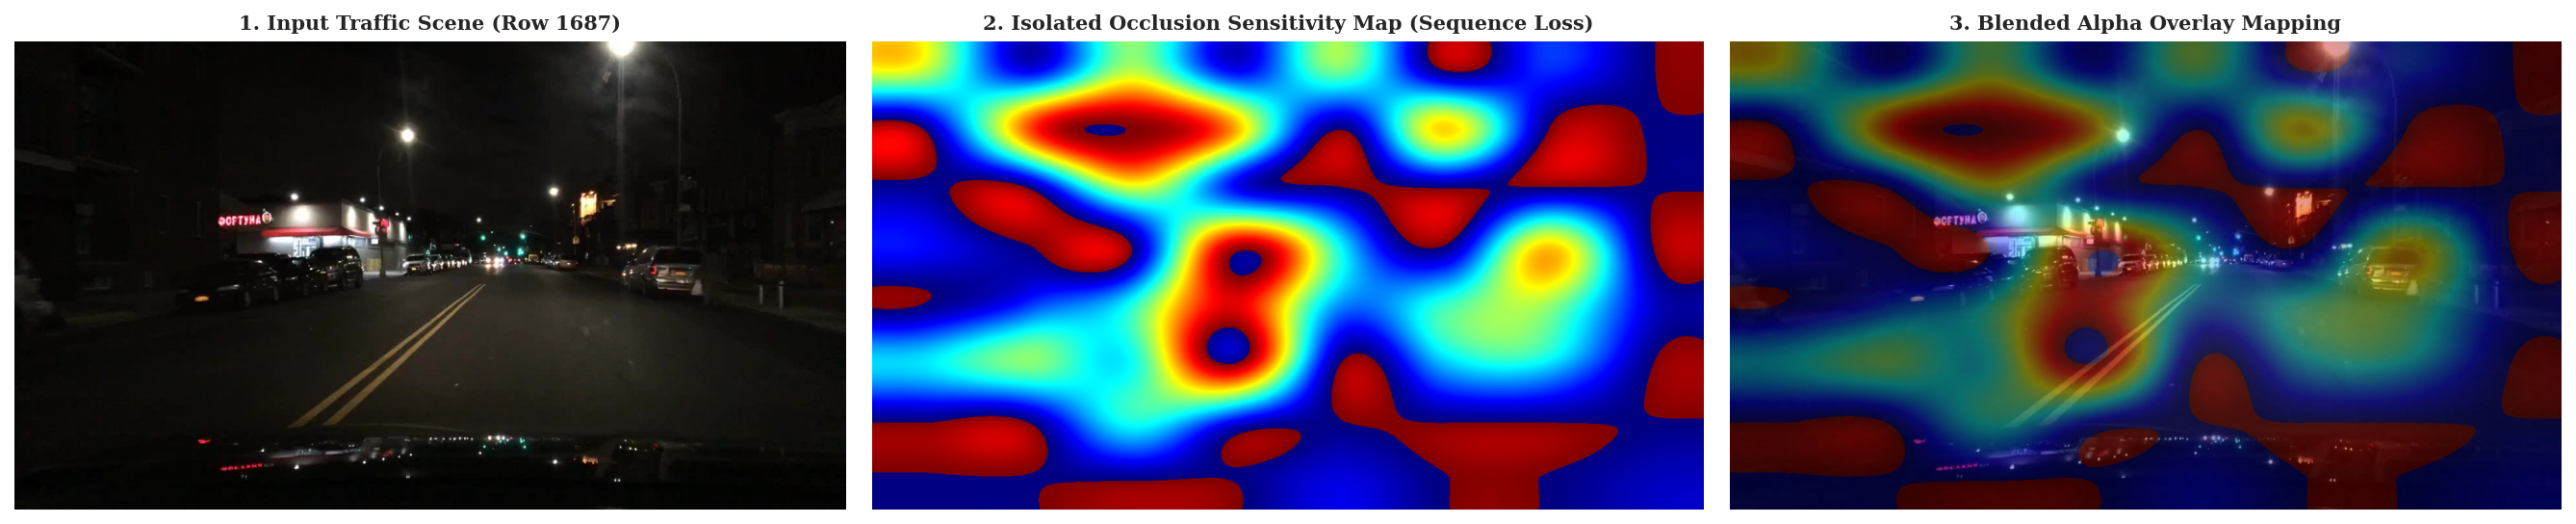

In [82]:
import torch
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Clear existing global forward hooks to reset memory state
try:
    for handle in list(torch.nn.modules.module._global_forward_hooks.values()):
        handle.remove()
except Exception:
    pass

# Filter dataset for Object Detection evaluation entries
df_sample = df_eval[df_eval["task_type"] == "Object Detection"].copy()

if len(df_sample) == 0:
    print("Halting: No 'Object Detection' task matches found in df_eval.")
else:
    # Randomly select an entry for evaluation
    random_row_idx = np.random.randint(0, len(df_sample))
    row = df_sample.iloc[random_row_idx]
    img_path = row.get("image_path" if "image_path" in row else "img_path", None)
    
    if img_path is None or not torch.cuda.is_available():
        print("Setup error: Verify image paths and GPU availability.")
    else:
        print("XAI ENGINE: NATIVE CE-LOSS PERTURBATION SCANNER")
        print("="*85)
        print(f"Selected Sample Row Index: {random_row_idx} / {len(df_sample)}")
        print("="*85)

        raw_image = Image.open(img_path).convert("RGB")
        target_device = next(model.parameters()).device
        
        # Pull the query text dynamically from the selected dataset row
        query_text = row["prompt"]
        print(f"Dynamic Dataset Query: {query_text}")

        # Establish the clean baseline output text using the dynamic query
        messages = [{"role": "user", "content": [{"type": "image", "image": raw_image}, {"type": "text", "text": query_text}]}]
        text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        
        # Process and transfer base inputs natively to target device
        inputs = processor(text=[text_prompt], images=raw_image, padding=True, return_tensors="pt")
        inputs_cuda = inputs.to(target_device)
        
        # Capture the length of the prompt to slice the output tokens correctly
        prompt_token_length = inputs_cuda["input_ids"].shape[1]
        
        # Generate complete baseline ground truth target sequence
        with torch.no_grad():
            generated_outputs = model.generate(
                **inputs_cuda, 
                max_new_tokens=150,
                do_sample=False,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id
            )
            
        # Isolate and decode only the newly generated tokens
        baseline_text = processor.decode(generated_outputs[0][prompt_token_length:], skip_special_tokens=True)
        print(f"Baseline Content Target Reference: {baseline_text}")

        # Evaluation helper function using the identical global query text variable
        def compute_patch_loss(image_obj):
            prompt_messages = [{"role": "user", "content": [{"type": "image", "image": image_obj}, {"type": "text", "text": query_text}]}]
            full_conversation = prompt_messages + [{"role": "assistant", "content": [{"type": "text", "text": baseline_text}]}]
            
            templated_text = processor.apply_chat_template(full_conversation, tokenize=False)
            inputs_eval = processor(text=[templated_text], images=image_obj, padding=True, return_tensors="pt")
            inputs_eval_cuda = inputs_eval.to(target_device)
            
            # Label alignment for loss processing
            labels = inputs_eval_cuda["input_ids"].clone()
            inputs_eval_cuda["labels"] = labels

            with torch.no_grad():
                outputs = model(**inputs_eval_cuda)
            
            return outputs.loss.item()

        print("Evaluating baseline sequence loss profile...")
        baseline_loss = compute_patch_loss(raw_image)
        
        orig_np = np.array(raw_image)
        h, w, c = orig_np.shape
        grid_rows, grid_cols = 8, 8
        patch_h, patch_w = h // grid_rows, w // grid_cols
        sensitivity_matrix = np.zeros((grid_rows, grid_cols))

        # Perform spatial occlusion sweeps across frame geometry
        print("Sweeping sliding occlusion patches across scene geometry...")
        for r in range(grid_rows):
            for c_idx in range(grid_cols):
                perturbed_np = orig_np.copy()
                y1, y2 = r * patch_h, (r + 1) * patch_h
                x1, x2 = c_idx * patch_w, (c_idx + 1) * patch_w
                perturbed_np[y1:y2, x1:x2] = 128  
                
                perturbed_img = Image.fromarray(perturbed_np)
                perturbed_loss = compute_patch_loss(perturbed_img)
                
                # Capture difference between baseline and perturbed sequence error
                sensitivity_matrix[r, c_idx] = max(0, perturbed_loss - baseline_loss)

        # Apply spatial variance normalization and outlier reduction
        low_bound, high_bound = np.percentile(sensitivity_matrix, [2, 98])
        sensitivity_matrix = np.clip(sensitivity_matrix, low_bound, high_bound)

        if np.max(sensitivity_matrix) > 0:
            heatmap_norm = (sensitivity_matrix - sensitivity_matrix.min()) / (sensitivity_matrix.max() - sensitivity_matrix.min() + 1e-8)
        else:
            heatmap_norm = sensitivity_matrix

        # Process spatial dimension mappings back to the shape of the original image
        heatmap_resized = cv2.resize(heatmap_norm, (w, h), interpolation=cv2.INTER_CUBIC)
        isolated_mask = np.uint8(255 * heatmap_resized)
        isolated_color_map = cv2.applyColorMap(isolated_mask, cv2.COLORMAP_JET)
        isolated_color_map = cv2.cvtColor(isolated_color_map, cv2.COLOR_BGR2RGB)
        blended_output = cv2.addWeighted(orig_np, 0.6, isolated_color_map, 0.4, 0)

        # Present clean diagnostic output array layout
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)
        axes[0].imshow(orig_np)
        axes[0].set_title(f"1. Input Traffic Scene (Row {random_row_idx})", fontsize=10, fontweight="bold")
        axes[0].axis("off")
        
        axes[1].imshow(isolated_color_map)
        axes[1].set_title("2. Isolated Occlusion Sensitivity Map (Sequence Loss)", fontsize=10, fontweight="bold")
        axes[1].axis("off")
        
        axes[2].imshow(blended_output)
        axes[2].set_title("3. Blended Alpha Overlay Mapping", fontsize=10, fontweight="bold")
        axes[2].axis("off")
        
        plt.tight_layout()
        plt.show()

**XAI - Multimodal Grad-CAM**

XAI ENGINE: MULTIMODAL GENERATION-GROUNDED GRAD-CAM
Selected Sample Row Index: 1337
Target Driving Image Path: C:/Users/becker/Documents/Thesis/dataset/images/val/be85bd88-d849c034.jpg
Dynamic Dataset Query: Give a full description of this scene including environment conditions.

Model Output Prediction: This is a daytime view from the driver’s perspective inside a vehicle on a multi-lane highway, likely during a work zone or road construction period. The sky is overcast with a uniform layer of gray clouds, indicating cloudy weather with no direct sunlight. The road surface is dark asphalt, and the lanes are clearly marked with white and yellow lines. The road appears to be in good condition, though construction activity is evident.

On the right side of the highway, there is a construction zone marked by multiple orange traffic cones and temporary barriers. A large red semi-truck is parked or stopped near the edge of the road, possibly as part of the construction crew or to assist wit

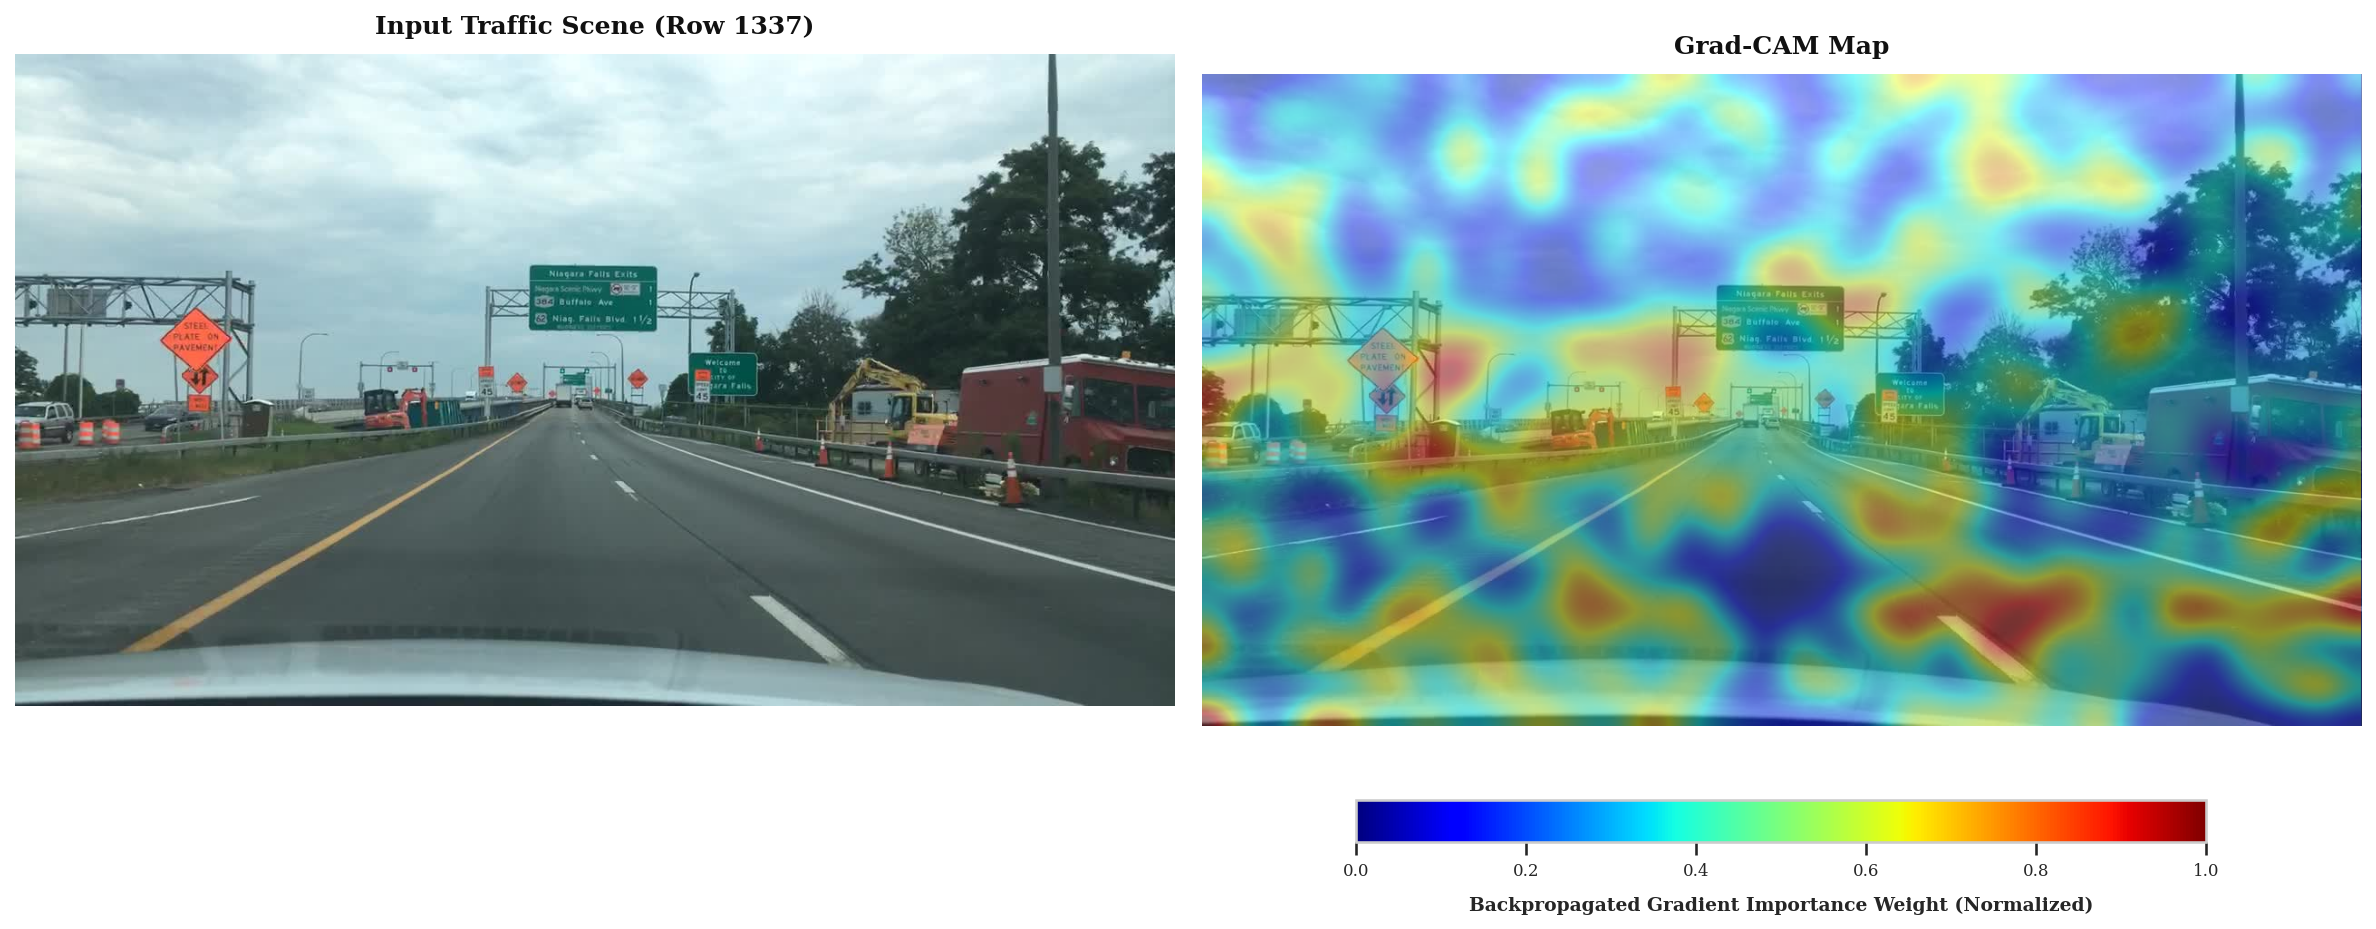

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import math
import cv2
from PIL import Image
from scipy.ndimage import zoom, gaussian_filter

class VLMGradCAM:
    #Hook manager to capture feature maps and gradients from a VLM's vision encoder backbone.
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output[0] if isinstance(output, tuple) else output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

def generate_vlm_gradcam(model, target_layer, model_inputs, target_token_index):
    #Executes a target backward pass to compute the 2D Grad-CAM activation map, featuring adaptive dimension extraction for Qwen's packed vision token layers.
   
    with torch.set_grad_enabled(True):
        # Initialize Hook Interface
        cam_hook = VLMGradCAM(model, target_layer)
        
        # Forward Pass unpacking full tensor metadata
        outputs = model(**model_inputs)
        logits = outputs.logits  # Shape: [Batch, Sequence_Length, Vocab_Size]
        
        # Isolate target token logit
        predicted_token_id = logits[0, target_token_index, :].argmax()
        target_logit = logits[0, target_token_index, predicted_token_id]
        
        # Zero out existing gradients and execute backward sweep
        model.zero_grad()
        target_logit.backward(retain_graph=True)
        
        # Safety assertion check to verify backpropagation reached the visual encoder
        if cam_hook.gradients is None or cam_hook.activations is None:
            cam_hook.remove_hooks()
            raise RuntimeError(
                "Grad-CAM hooks failed to capture tensors."
            )
            
        grads = cam_hook.gradients.detach().cpu().float()
        acts = cam_hook.activations.detach().cpu().float()
        cam_hook.remove_hooks()
        
        # Dynamic Squeezing to drop batch dimension safely
        if grads.dim() == 3:
            grads = grads[0]
        if acts.dim() == 3:
            acts = acts[0]
        
        # Compute channel importance weights by pooling over the Token dimension
        weights = torch.mean(grads, dim=0)  # Shape: [Hidden_Dim]
        
        # Vectorized channel-activation blending
        cam = torch.sum(acts * weights, dim=-1)  # Shape: [Tokens]
        
        # Apply ReLU to retain positive influences
        cam = torch.clamp(cam, min=0)
        num_spatial_tokens = cam.shape[0]
        
        # Adaptive Metadata Dimension Selector (Fixes the Aspect Ratio Distortion Bug)
        if "image_grid_thw" in model_inputs:
            thw = model_inputs["image_grid_thw"].cpu().numpy()[0]
            h_raw, w_raw = int(thw[1]), int(thw[2])
            
            # Case A: Hook matches raw unmerged patch sequence (Standard for ViT Blocks)
            if h_raw * w_raw == num_spatial_tokens:
                cam = cam.view(h_raw, w_raw).numpy()
                if cam.max() > 0:
                    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
                return cam
                
            # Case B: Hook matches merged patch sequence (Post-spatial-merge layer)
            h_merged, w_merged = h_raw // 2, w_raw // 2
            if h_merged * w_merged == num_spatial_tokens:
                cam = cam.view(h_merged, w_merged).numpy()
                if cam.max() > 0:
                    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
                return cam
                
        # Mathematical square fallback layout if metadata dimension matching fails completely
        grid_size = int(math.sqrt(num_spatial_tokens))
        if grid_size * grid_size == num_spatial_tokens:
            cam = cam.view(grid_size, grid_size).numpy()
        else:
            grid_size = int(math.ceil(math.sqrt(num_spatial_tokens)))
            padding = (grid_size * grid_size) - num_spatial_tokens
            cam = torch.cat([cam, torch.zeros(padding)])
            cam = cam.view(grid_size, grid_size).numpy()
            
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
            
        return cam


# GENERATION-GROUNDED RUNTIME INFERENCE & DASHBOARD RENDERING

# Secure an active sample row and pull the actual image path from your dataframe
df_sample = df_eval[df_eval["task_type"] == "Object Detection"].copy()

if len(df_sample) == 0:
    raise ValueError("The evaluation dataframe does not contain any rows matching 'Object Detection'.")

random_row_idx = np.random.randint(0, len(df_sample))
row = df_sample.iloc[random_row_idx]

img_path = row.get("image_path", row.get("img_path", None))
if img_path is None:
    raise KeyError("Could not find an 'image_path' or 'img_path' column in your dataframe.")

print("XAI ENGINE: MULTIMODAL GENERATION-GROUNDED GRAD-CAM")
print("="*85)
print(f"Selected Sample Row Index: {random_row_idx}")
print(f"Target Driving Image Path: {img_path}")
print("="*85)

raw_img = Image.open(img_path).convert("RGB")
img_np = np.array(raw_img)

# Pull the text prompt dynamically from the dataset row
query_text = row["prompt"]
print(f"Dynamic Dataset Query: {query_text}\n")

# Reconstruct the template prompt string using the dynamic query variable
messages = [{"role": "user", "content": [{"type": "image", "image": raw_img}, {"type": "text", "text": query_text}]}]
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# Process base inputs
inputs = processor(text=[text_prompt], images=raw_img, padding=True, return_tensors="pt")
target_device = next(model.parameters()).device
inputs_cuda = {k: v.to(target_device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

# 1. STEP 1: Generate the model's actual prediction text without gradients active
with torch.no_grad():
    generated_ids = model.generate(**inputs_cuda, max_new_tokens=200, do_sample=False)
    
input_len = inputs_cuda["input_ids"].shape[1]
generated_tokens_only = generated_ids[0][input_len:]
prediction_text = processor.decode(generated_tokens_only, skip_special_tokens=True)
print(f"Model Output Prediction: {prediction_text}")

# 2. STEP 2: Reconstruct the full sequence to track gradients through the output
full_input_ids = generated_ids  # The full combined token tensor [Prompt + Response]
total_sequence_length = full_input_ids.shape[1]

# Build a fully updated model inputs dictionary matching the complete sequence length
grad_inputs = {
    "input_ids": full_input_ids,
    "attention_mask": torch.ones_like(full_input_ids).to(target_device)
}
if "image_grid_thw" in inputs_cuda:
    grad_inputs["image_grid_thw"] = inputs_cuda["image_grid_thw"]
if "pixel_values" in inputs_cuda:
    grad_inputs["pixel_values"] = inputs_cuda["pixel_values"]

# 3. STEP 3: Target a content token from the actual response body instead of the prompt
if len(generated_tokens_only) > 0:
    target_idx = input_len + (len(generated_tokens_only) // 2)
else:
    target_idx = input_len - 1

targeted_token_string = processor.decode([full_input_ids[0][target_idx]])
print(f"Sequence Matrix Verified | Total Context Length: {total_sequence_length}")
print(f"Targeting Index: {target_idx} (Decoded Token Asset: '{targeted_token_string}')")
print("="*85)

# Qwen Architecture Layer Routing
try:
    if hasattr(model, "visual") and hasattr(model.visual, "blocks"):
        target_layer = model.visual.blocks[-1]
    elif hasattr(model, "model") and hasattr(model.model, "visual") and hasattr(model.model.visual, "blocks"):
        target_layer = model.model.visual.blocks[-1]
    else:
        target_layer = [m for m in model.modules() if "Block" in m.__class__.__name__ or "Layer" in m.__class__.__name__][-1]
except Exception as e:
    raise RuntimeError(f"Could not map vision backbone architecture to a valid target layer: {e}")

# Generate 2D Grad-CAM weights relative to your generated word/coordinate token
cam_map = generate_vlm_gradcam(model, target_layer, grad_inputs, target_token_index=target_idx)

# Smooth the raw low-resolution map to suppress high-frequency token grid noise
cam_map_smoothed = gaussian_filter(cam_map, sigma=0.6)

# Upsample the smoothed matrix directly to native camera image dimensions
scale_y = img_np.shape[0] / cam_map_smoothed.shape[0]
scale_x = img_np.shape[1] / cam_map_smoothed.shape[1]
high_res_cam = zoom(cam_map_smoothed, (scale_y, scale_x), order=3) 

# Re-normalize after scaling adjustments
if high_res_cam.max() > 0:
    high_res_cam = (high_res_cam - high_res_cam.min()) / (high_res_cam.max() - high_res_cam.min() + 1e-8)


# VISUALIZATION

# Generate the raw continuous JET heatmap overlay
heatmap_uint8 = np.uint8(255 * high_res_cam)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
continuous_blend = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

# Render the 2-Panel Comparative Layout
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150, facecolor="#ffffff")

# Panel 1: Visual Ground Truth Baseline
axes[0].imshow(img_np)
axes[0].set_title(f"Input Traffic Scene (Row {random_row_idx})", fontsize=12, fontweight="bold", color="#111111", pad=10)
axes[0].axis("off")

# Panel 2: Continuous Gradient Distribution (The Academic Standard)
axes[1].imshow(continuous_blend)
axes[1].set_title(f"Grad-CAM Map", fontsize=12, fontweight="bold", color="#111111", pad=10)
axes[1].axis("off")

# Add a clean, horizontal colorbar anchored beneath Panel 2
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='jet'), 
    ax=axes[1], 
    orientation='horizontal', 
    fraction=0.046, 
    pad=0.08
)
cbar.set_label('Backpropagated Gradient Importance Weight (Normalized)', fontsize=9, fontweight='bold', labelpad=8)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("gradcam_2panel_evaluation.png", facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

## 12. Training Summary

In [12]:
# Print comprehensive training summary

print("="*80)
print("TRAINING SUMMARY")
print("="*80)
print()
print("MODEL:")
print(f"  Base Model: {CONFIG['model_name']}")
print(f"  Adapter Type: LoRA (Parameter Efficient Fine-tuning)")
print()
print("TRAINING CONFIG:")
print(f"  Epochs: {CONFIG['num_train_epochs']}")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Gradient accumulation: {CONFIG['gradient_accumulation_steps']}")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print()
print("OPTIMIZATION:")
print(f"  Gradient checkpointing: {CONFIG['gradient_checkpointing']}")
print(f"  BF16 precision: {CONFIG['bf16']}")
print(f"  Max gradient norm: {CONFIG['max_grad_norm']}")
print()
print("LORA CONFIGURATION:")
print(f"  Rank: {CONFIG['lora_r']}")
print(f"  Alpha: {CONFIG['lora_alpha']}")
print(f"  Dropout: {CONFIG['lora_dropout']}")
print(f"  Target modules: {len(CONFIG['target_modules'])}")
print()
print("="*80)

TRAINING SUMMARY

MODEL:
  Base Model: Qwen/Qwen3-VL-4B-Instruct
  Adapter Type: LoRA (Parameter Efficient Fine-tuning)

TRAINING CONFIG:
  Epochs: 1
  Batch size: 4
  Gradient accumulation: 2
  Learning rate: 0.0002

OPTIMIZATION:
  Gradient checkpointing: True
  BF16 precision: True
  Max gradient norm: 1.0

LORA CONFIGURATION:
  Rank: 16
  Alpha: 32
  Dropout: 0.05
  Target modules: 7

